# Pakistani Diabetes Risk Analysis
## Data Visualization & Machine Learning Project

**Dataset:** Pakistani Diabetes Dataset (Kaggle)  
**Goal:** Explore diabetes risk factors in Pakistani patients and build predictive ML models


# Installing & Importing Libraries

In [ ]:
# Install required packages
!pip install xgboost shap --quiet

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibrationDisplay
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)


In [4]:
import shap
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PAL = {'Non-Diabetic': '#2ecc71', 'Diabetic': '#e74c3c'}
C0, C1 = '#2ecc71', '#e74c3c'


# Loading Dataset

In [5]:
df = pd.read_csv("Pakistani_Diabetes_Dataset.csv")
df.columns = df.columns.str.strip()
print("Raw columns BEFORE rename:")
print(list(df.columns))

Raw columns BEFORE rename:
['Age', 'Gender', 'Rgn', 'wt', 'BMI', 'wst', 'sys', 'dia', 'his', 'A1c', 'B.S.R', 'vision', 'Exr', 'dipsia', 'uria', 'Dur', 'neph', 'HDL', 'Outcome']


# Renaming Columns Names for better Understanding

In [9]:
raw_rename_map = {
    'Age': 'Age',
    'Gender': 'Gender',
    'Region': 'Rgn',
    'Rgn': 'Rgn',
    'Wt': 'Weight',
    'Wt.': 'Weight',
    'Wst': 'Waist',
    'sys': 'Systolic_BP',
    'Sys': 'Systolic_BP',
    'dia': 'Diastolic_BP',
    'Dia': 'Diastolic_BP',
    'his': 'Family_History',
    'His': 'Family_History',
    'Alc': 'A1c',
    'HbA1c': 'A1c',
    'B.S.#': 'Blood_Sugar',
    'B.S': 'Blood_Sugar',
    'B_S': 'Blood_Sugar',
    'Blood_Sugar': 'Blood_Sugar',
    'vision': 'Vision_Problems',
    'Vision': 'Vision_Problems',
    'Exer': 'Exr',
    'Exr': 'Exr',
    'Exercise_Min': 'Exr',
    'dipsia': 'Polydipsia',
    'Dipsia': 'Polydipsia',
    'uria': 'Polyuria',
    'Uria': 'Polyuria',
    'Dur': 'Duration',
    'Duration': 'Duration',
    'neph': 'Nephropathy',
    'Neph': 'Nephropathy',
    'HDL': 'HDL_Cholesterol',
    'Outcome': 'Outcome',
    'BMI': 'BMI',
    'Weight': 'Weight',
    'Waist': 'Waist',
    'Systolic_BP': 'Systolic_BP',
    'Diastolic_BP': 'Diastolic_BP',
    'Family_History': 'Family_History',
    'A1c': 'A1c',
    'Vision_Problems': 'Vision_Problems',
    'Polydipsia': 'Polydipsia',
    'Polyuria': 'Polyuria',
    'Nephropathy': 'Nephropathy',
    'HDL_Cholesterol': 'HDL_Cholesterol',
}

rename_map = {k: v for k, v in raw_rename_map.items() if k in df.columns}
df.rename(columns=rename_map, inplace=True)

print("Columns AFTER rename:")
print(list(df.columns))


Columns AFTER rename:
['Age', 'Gender', 'Rgn', 'wt', 'BMI', 'wst', 'Systolic_BP', 'Diastolic_BP', 'Family_History', 'A1c', 'B.S.R', 'Vision_Problems', 'Exr', 'Polydipsia', 'Polyuria', 'Nephropathy', 'HDL_Cholesterol', 'Outcome']


In [10]:
# Dropping Duration
if 'Duration' in df.columns:
    df.drop(columns=['Duration'], inplace=True)
    print('Dropped Duration column — post-diagnosis leakage.')

In [11]:
# Confirming critical columns
REQUIRED = ['Age', 'Gender', 'Rgn', 'Weight', 'BMI', 'Waist',
            'Systolic_BP', 'Diastolic_BP', 'Family_History',
            'A1c', 'Blood_Sugar', 'Vision_Problems', 'Exr',
            'Polydipsia', 'Polyuria', 'Nephropathy', 'HDL_Cholesterol', 'Outcome']

missing_cols = [c for c in REQUIRED if c not in df.columns]
if missing_cols:
    print(f"These expected columns are MISSING after rename: {missing_cols}")
    print("Check your CSV headers against the rename map above.")
else:
    print("All required columns present!")


These expected columns are MISSING after rename: ['Weight', 'Waist', 'Blood_Sugar']
Check your CSV headers against the rename map above.


In [12]:
print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Dataset Shape: (912, 18)
Columns: ['Age', 'Gender', 'Rgn', 'wt', 'BMI', 'wst', 'Systolic_BP', 'Diastolic_BP', 'Family_History', 'A1c', 'B.S.R', 'Vision_Problems', 'Exr', 'Polydipsia', 'Polyuria', 'Nephropathy', 'HDL_Cholesterol', 'Outcome']


,Age,Gender,Rgn,wt,BMI,wst,Systolic_BP,Diastolic_BP,Family_History,A1c,B.S.R,Vision_Problems,Exr,Polydipsia,Polyuria,Nephropathy,HDL_Cholesterol,Outcome
0,60.0,1,0,76.0,29.90,41.0,130,90,0,8.90,278,0,30,1,0,0,60,1
1,57.0,1,1,64.0,24.30,39.0,120,80,1,8.50,165,0,20,1,1,0,42,1
2,58.0,0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0,54,0
3,27.0,0,1,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0,57,0
4,56.0,1,0,70.0,25.80,43.0,125,90,0,8.30,139,1,40,1,0,1,53,1


# Exploratory Data Overview

In [13]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              912 non-null    float64
 1   Gender           912 non-null    int64  
 2   Rgn              912 non-null    int64  
 3   wt               912 non-null    float64
 4   BMI              912 non-null    float64
 5   wst              912 non-null    float64
 6   Systolic_BP      912 non-null    int64  
 7   Diastolic_BP     912 non-null    int64  
 8   Family_History   912 non-null    int64  
 9   A1c              912 non-null    float64
 10  B.S.R            912 non-null    int64  
 11  Vision_Problems  912 non-null    int64  
 12  Exr              912 non-null    int64  
 13  Polydipsia       912 non-null    int64  
 14  Polyuria         912 non-null    int64  
 15  Nephropathy      912 non-null    int64  
 16  HDL_Cholesterol  912 non-null    int64  
 17  Ou

In [14]:
print('Statistical Summary:')
display(df.describe().round(2))

Statistical Summary:


,Age,Gender,Rgn,wt,BMI,wst,Systolic_BP,Diastolic_BP,Family_History,A1c,B.S.R,Vision_Problems,Exr,Polydipsia,Polyuria,Nephropathy,HDL_Cholesterol,Outcome
count,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00,912.00
mean,36.32,0.55,0.29,69.36,25.63,35.46,129.64,82.35,0.59,6.86,165.47,0.49,14.43,0.38,0.33,0.17,45.96,0.53
std,13.52,0.50,0.45,12.17,8.25,3.89,19.76,11.83,0.49,2.20,84.73,0.50,15.60,0.49,0.47,0.38,6.81,0.50
min,12.00,0.00,0.00,30.00,2.84,24.00,90.00,20.00,0.00,0.10,70.00,0.00,0.00,0.00,0.00,0.00,30.00,0.00
25%,22.75,0.00,0.00,60.00,22.50,32.50,120.00,73.00,0.00,5.00,96.00,0.00,0.00,0.00,0.00,0.00,41.00,0.00
50%,36.00,1.00,0.00,69.00,25.24,35.00,126.00,80.00,1.00,6.10,130.50,0.00,15.00,0.00,0.00,0.00,46.00,1.00
75%,48.00,1.00,1.00,77.00,28.30,38.00,138.00,90.00,1.00,8.50,217.25,1.00,25.00,1.00,1.00,0.00,51.00,1.00
max,70.00,1.00,1.00,110.00,233.79,67.00,245.00,115.00,1.00,14.00,464.00,1.00,120.00,1.00,1.00,1.00,62.00,1.00


In [15]:
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing Values:
Age                0
Gender             0
Rgn                0
wt                 0
BMI                0
wst                0
Systolic_BP        0
Diastolic_BP       0
Family_History     0
A1c                0
B.S.R              0
Vision_Problems    0
Exr                0
Polydipsia         0
Polyuria           0
Nephropathy        0
HDL_Cholesterol    0
Outcome            0
dtype: int64

Total missing: 0


In [16]:
print(f'Duplicates: {df.duplicated().sum()}')

Duplicates: 3


# Data Preprocessing

### Check biologically impossible zero values

In [17]:
zero_check_cols_candidates = ['BMI', 'Blood_Sugar', 'A1c', 'Systolic_BP', 'Diastolic_BP', 'Weight', 'HDL_Cholesterol']
zero_check_cols = [c for c in zero_check_cols_candidates if c in df.columns]
print('Zero counts in key numeric columns (potential hidden nulls):')
for col in zero_check_cols:
    count = (df[col] == 0).sum()
    if count > 0:
        print(f' {col}: {count} zeros, replacing with median')
        df[col].replace(0, np.nan, inplace=True)
        df[col].fillna(df[col].median(), inplace=True)
    else:
        print(f'{col}: No zeros')

Zero counts in key numeric columns (potential hidden nulls):
BMI: No zeros
A1c: No zeros
Systolic_BP: No zeros
Diastolic_BP: No zeros
HDL_Cholesterol: No zeros


### Outlier detection using IQR

In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Outcome']
outlier_info = {}
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = count
outlier_df = pd.DataFrame.from_dict(outlier_info, orient='index', columns=['Outlier Count'])
print('Outlier counts per feature (IQR method):')
display(outlier_df[outlier_df['Outlier Count'] > 0].sort_values('Outlier Count', ascending=False))

Outlier counts per feature (IQR method):


,Outlier Count
Nephropathy,156
Systolic_BP,55
BMI,12
B.S.R,9
wt,7
Diastolic_BP,4
wst,4
Exr,3
A1c,1


### Visualizing outliers

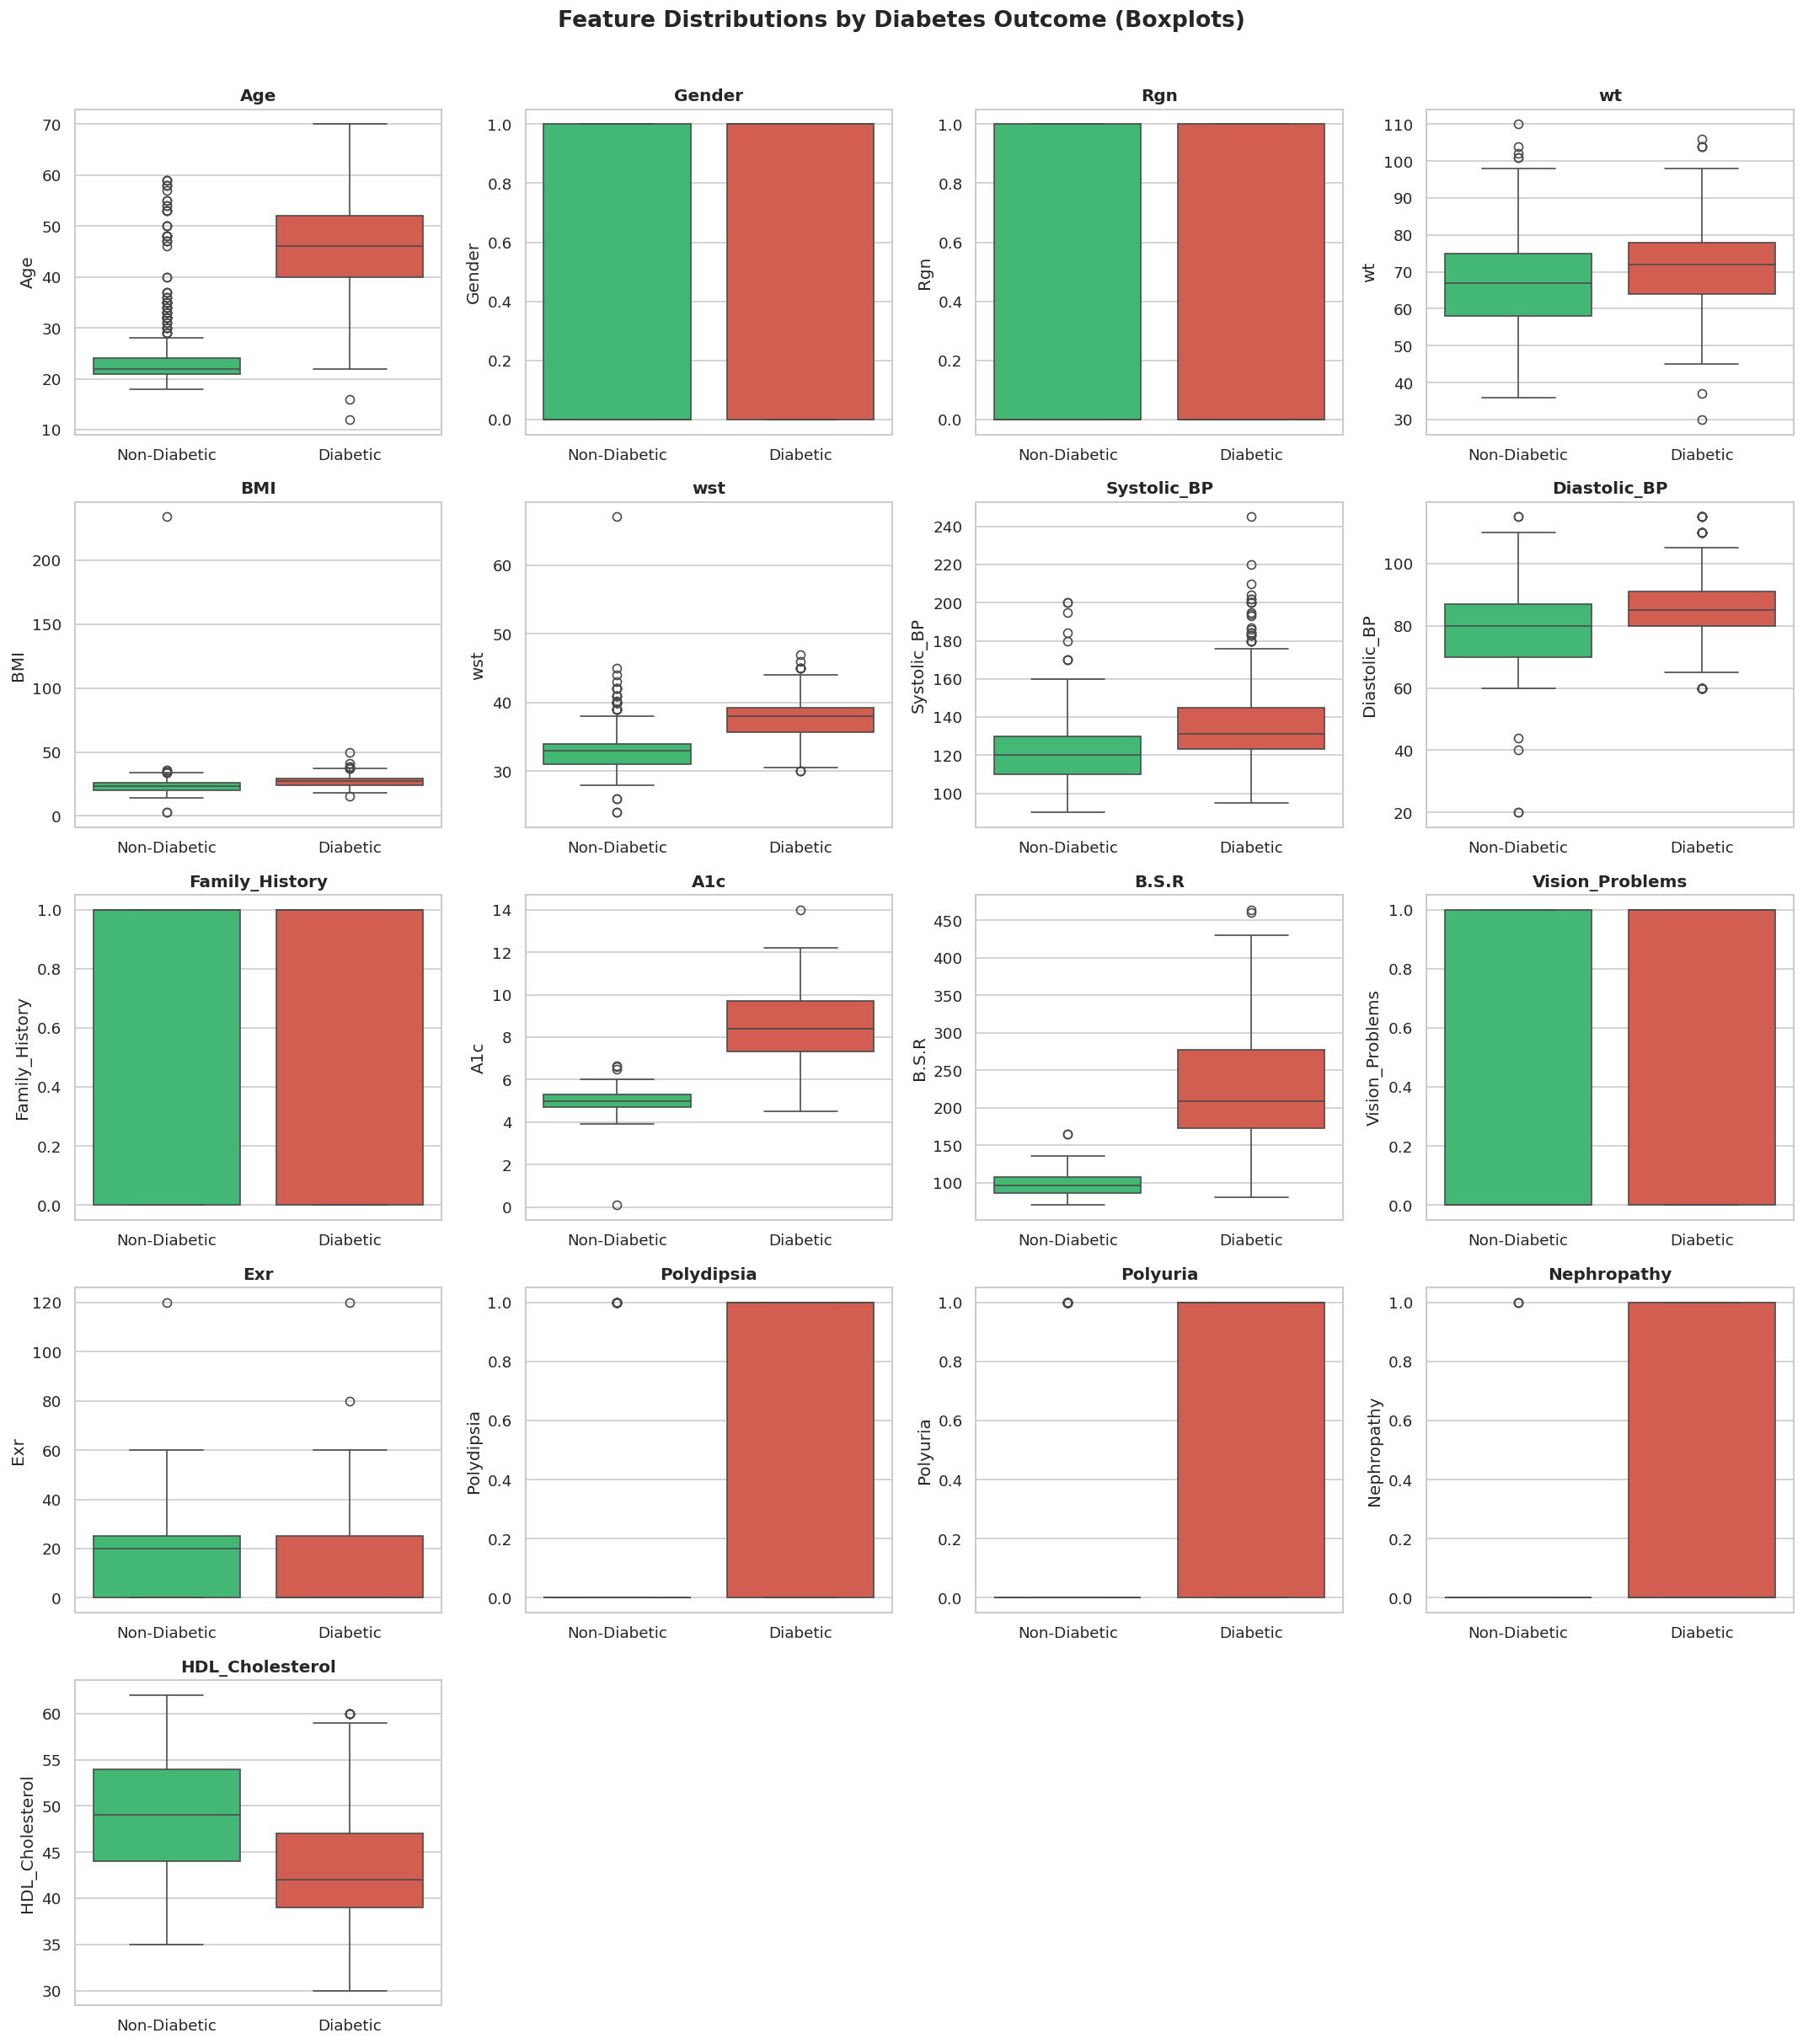

In [19]:
df['Outcome_Label'] = df['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})
plot_cols_candidates = [c for c in numeric_cols if c in df.columns]
n_cols = 4
n_rows = int(np.ceil(len(plot_cols_candidates) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(plot_cols_candidates):
    sns.boxplot(data=df, x='Outcome_Label', y=col, palette=PAL,
                order=['Non-Diabetic', 'Diabetic'], ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
for j in range(len(plot_cols_candidates), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Diabetes Outcome (Boxplots)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_by_outcome.png', bbox_inches='tight')
plt.show()

### Class balance check

Class Distribution:
Outcome
0    426
1    486
Name: count, dtype: int64

Balance Ratio (0:1): 0.88


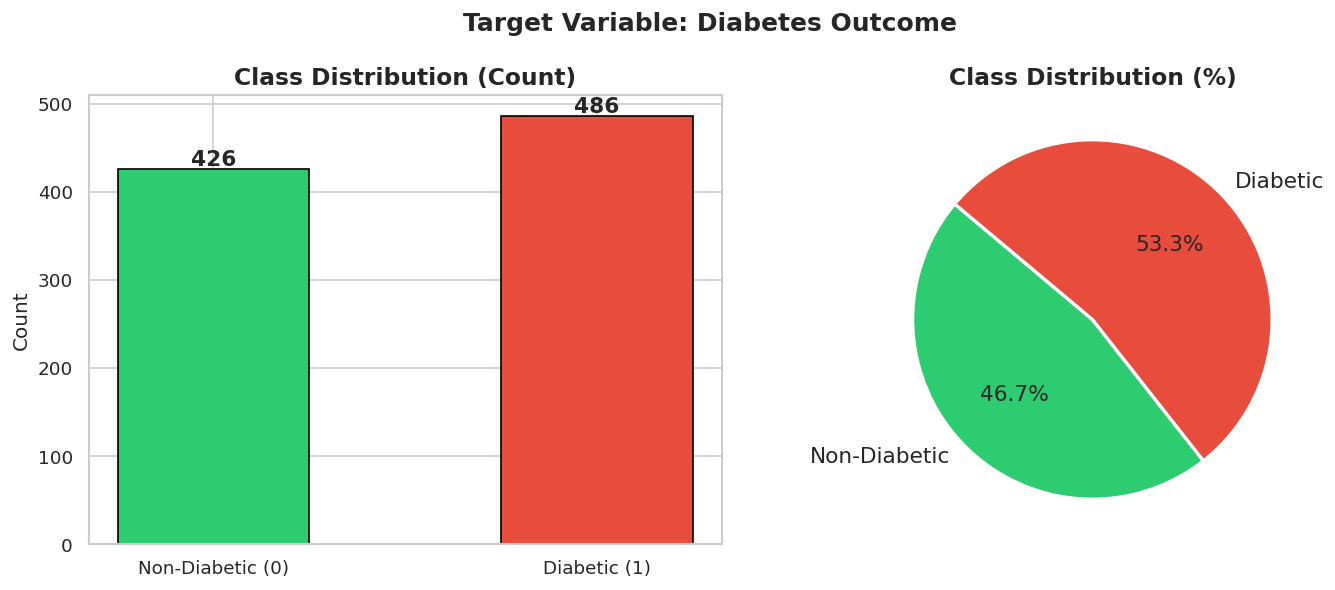

In [20]:
outcome_counts = df['Outcome'].value_counts().sort_index()
print('Class Distribution:')
print(outcome_counts)
print(f'\nBalance Ratio (0:1): {outcome_counts[0]/outcome_counts[1]:.2f}')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
bars = ax1.bar(['Non-Diabetic (0)', 'Diabetic (1)'], outcome_counts.values,
               color=[C0, C1], edgecolor='black', width=0.5)
for bar, val in zip(bars, outcome_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f'{val}', ha='center', fontweight='bold', fontsize=13)
ax1.set_title('Class Distribution (Count)', fontweight='bold', fontsize=14)
ax1.set_ylabel('Count')

ax2.pie(outcome_counts.values, labels=['Non-Diabetic', 'Diabetic'],
        colors=[C0, C1], autopct='%1.1f%%', startangle=140,
        textprops={'fontsize': 13}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Class Distribution (%)', fontweight='bold', fontsize=14)

plt.suptitle('Target Variable: Diabetes Outcome', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

# Exploratory Data Analysis & Visualisations

### Feature distributions (KDE + Histogram)

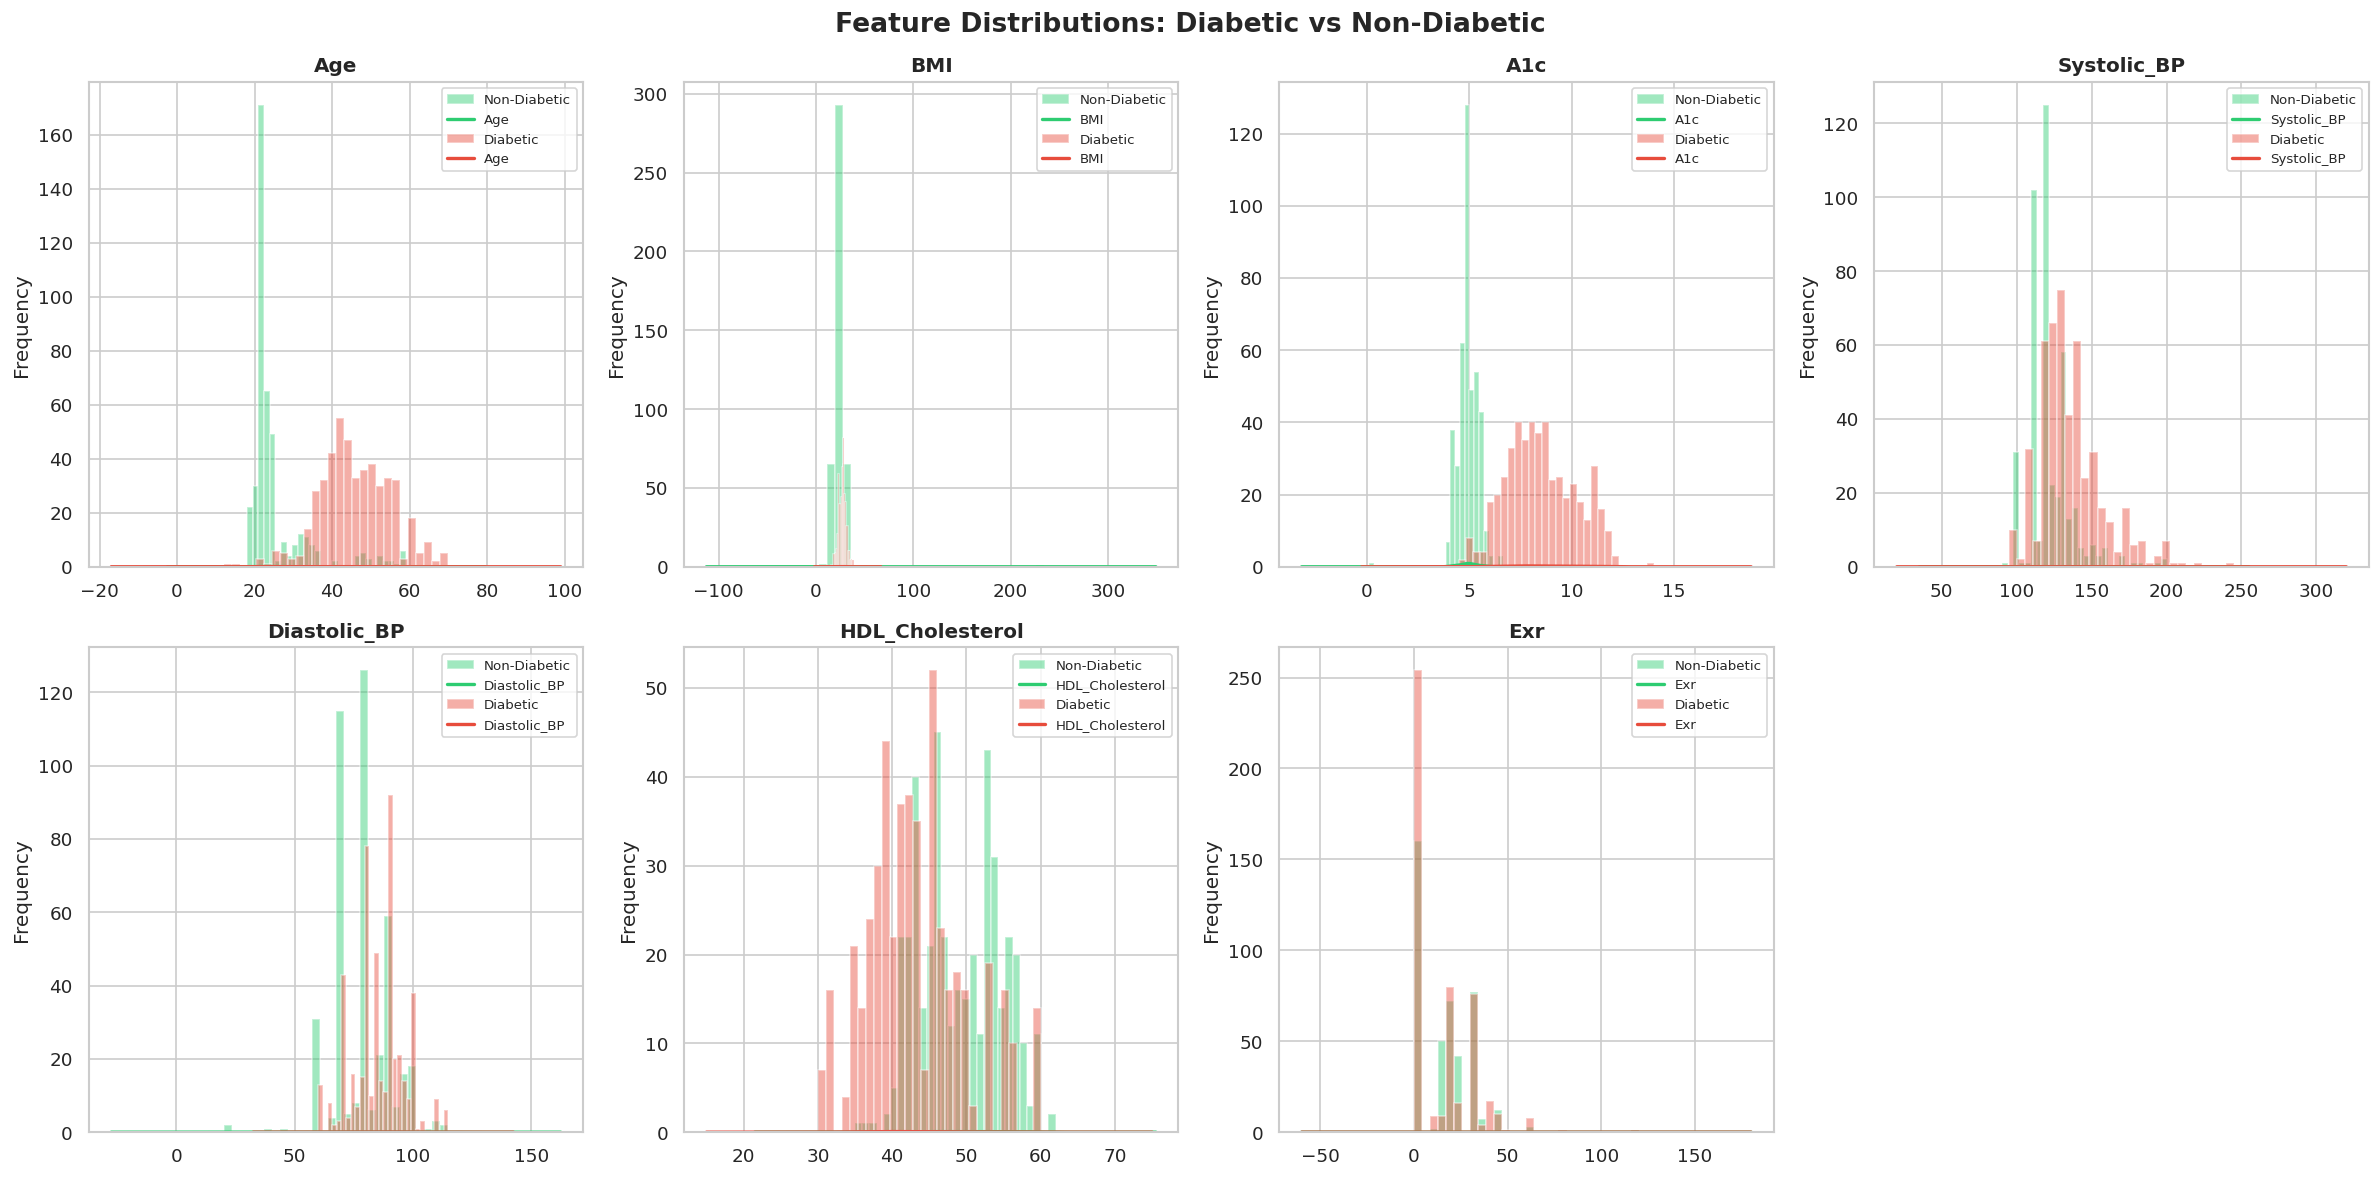

In [21]:
cont_cols_candidates = ['Age', 'BMI', 'Blood_Sugar', 'A1c', 'Systolic_BP', 'Diastolic_BP',
                         'Weight', 'Waist', 'HDL_Cholesterol', 'Exr']
cont_cols = [c for c in cont_cols_candidates if c in df.columns]

n_cols = 4
n_rows = int(np.ceil(len(cont_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    for outcome, color, label in zip([0, 1], [C0, C1], ['Non-Diabetic', 'Diabetic']):
        subset = df[df['Outcome'] == outcome][col]
        axes[i].hist(subset, bins=28, alpha=0.45, color=color, label=label, edgecolor='white')
        subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Frequency')
for j in range(len(cont_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Diabetic vs Non-Diabetic', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

### Correlation Heatmap


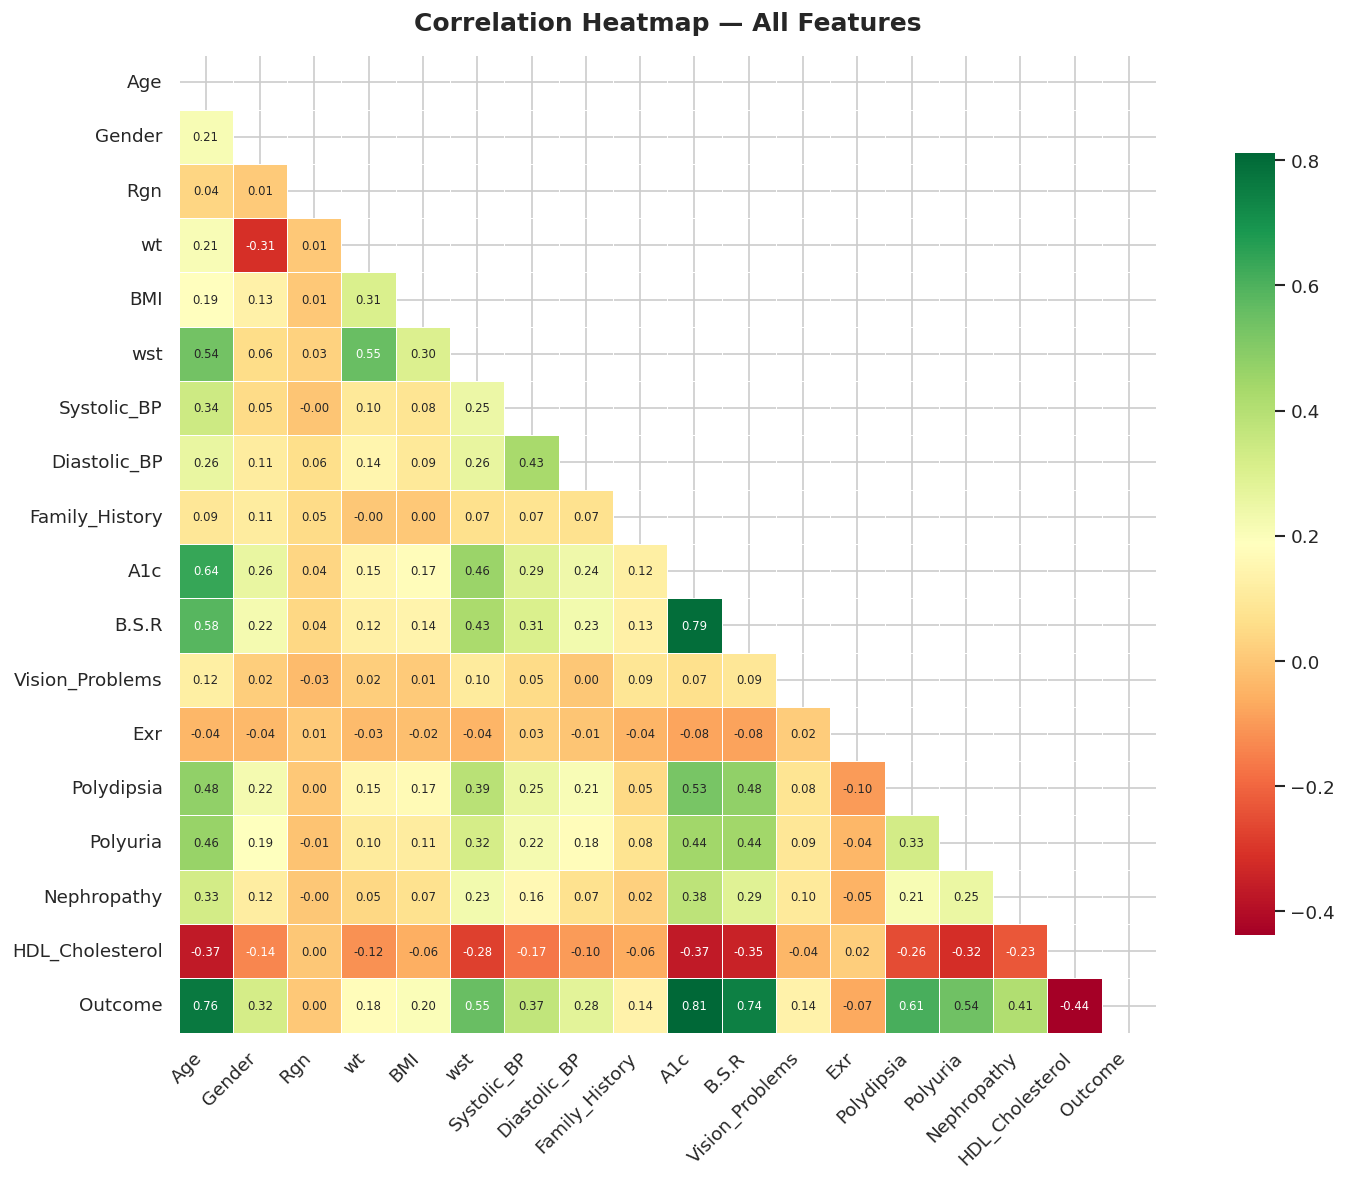


Top correlations with Outcome:
A1c                0.812
Age                0.764
B.S.R              0.744
Polydipsia         0.610
wst                0.555
Polyuria           0.542
Nephropathy        0.408
Systolic_BP        0.369
Gender             0.322
Diastolic_BP       0.279
BMI                0.205
wt                 0.175
Vision_Problems    0.138
Family_History     0.136
Rgn                0.002
Exr               -0.072
HDL_Cholesterol   -0.438
Name: Outcome, dtype: float64


In [22]:
heatmap_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14, 10))
corr = heatmap_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
plt.title('Correlation Heatmap — All Features', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\nTop correlations with Outcome:')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))

### Gender Analysis


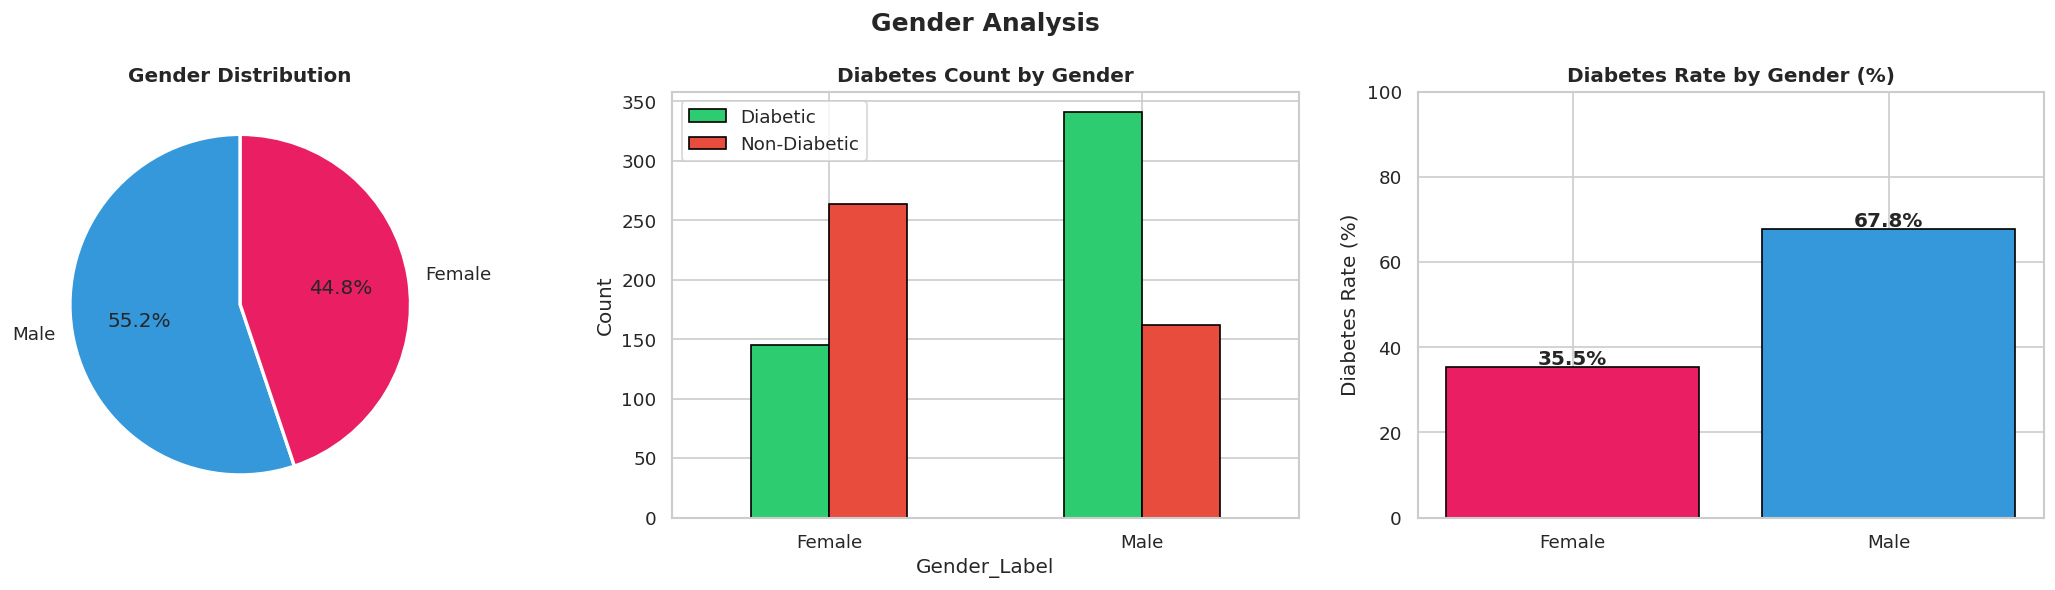

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Plot 1: Gender distribution pie
gender_counts = df['Gender'].value_counts()
gender_labels = ['Female' if g == 0 else 'Male' for g in gender_counts.index]
axes[0].pie(gender_counts.values, labels=gender_labels,
            colors=['#3498db', '#e91e63'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Gender Distribution', fontweight='bold')

# Plot 2: Diabetes Count by Gender — FIX: build pivot without unstack
gender_outcome = df.groupby(['Gender', 'Outcome']).size().reset_index(name='count')
gender_outcome['Gender_Label'] = gender_outcome['Gender'].map({0: 'Female', 1: 'Male'})
gender_outcome['Outcome_Label'] = gender_outcome['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

pivot = gender_outcome.pivot(index='Gender_Label', columns='Outcome_Label', values='count').fillna(0)
pivot.plot(kind='bar', ax=axes[1], color=[C0, C1], edgecolor='black', rot=0)
axes[1].set_title('Diabetes Count by Gender', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend()

# Plot 3: Diabetes Rate by Gender
gender_rate = df.groupby('Gender')['Outcome'].mean() * 100
gender_rate.index = ['Female', 'Male']
bars = axes[2].bar(gender_rate.index, gender_rate.values,
                    color=['#e91e63', '#3498db'], edgecolor='black')
for bar, val in zip(bars, gender_rate.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Diabetes Rate by Gender (%)', fontweight='bold')
axes[2].set_ylabel('Diabetes Rate (%)')
axes[2].set_ylim(0, 100)

plt.suptitle('Gender Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('gender_analysis.png', bbox_inches='tight')
plt.show()

### Age & BMI Analysis


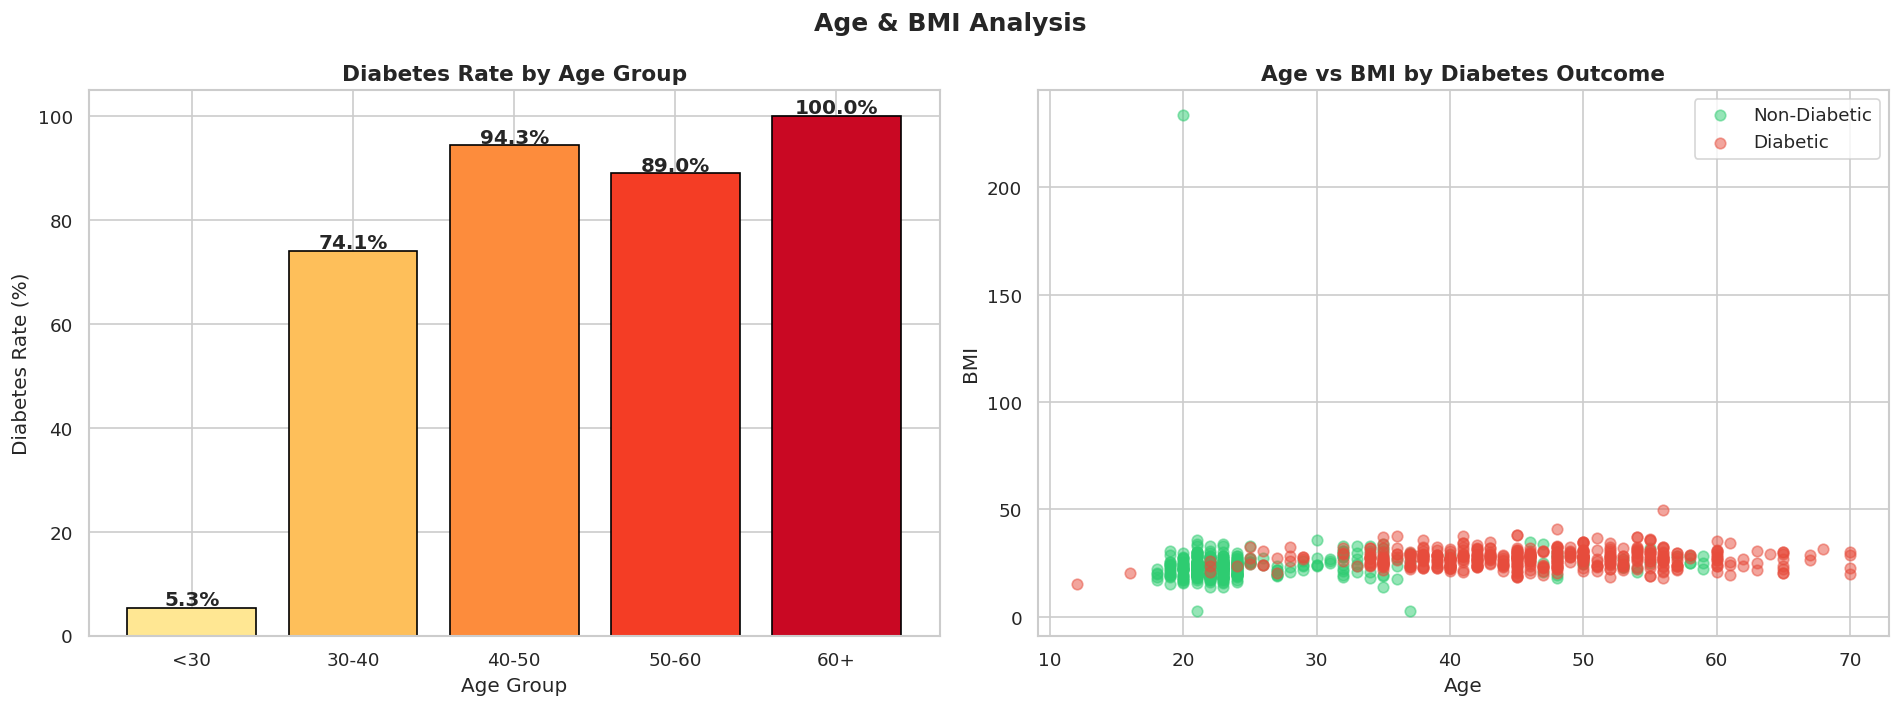

In [24]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100],
                          labels=['<30', '30-40', '40-50', '50-60', '60+'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

age_rate = df.groupby('Age_Group', observed=True)['Outcome'].mean() * 100
bars = axes[0].bar(age_rate.index, age_rate.values,
                    color=sns.color_palette('YlOrRd', len(age_rate)), edgecolor='black')
for bar, val in zip(bars, age_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Diabetes Rate by Age Group', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Diabetes Rate (%)')

for outcome, color, label in zip([0, 1], [C0, C1], ['Non-Diabetic', 'Diabetic']):
    subset = df[df['Outcome'] == outcome]
    axes[1].scatter(subset['Age'], subset['BMI'], alpha=0.5, color=color, label=label, s=40)
axes[1].set_title('Age vs BMI by Diabetes Outcome', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('BMI')
axes[1].legend()

plt.suptitle('Age & BMI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('age_bmi_analysis.png', bbox_inches='tight')
plt.show()

### Clinical Markers Analysis


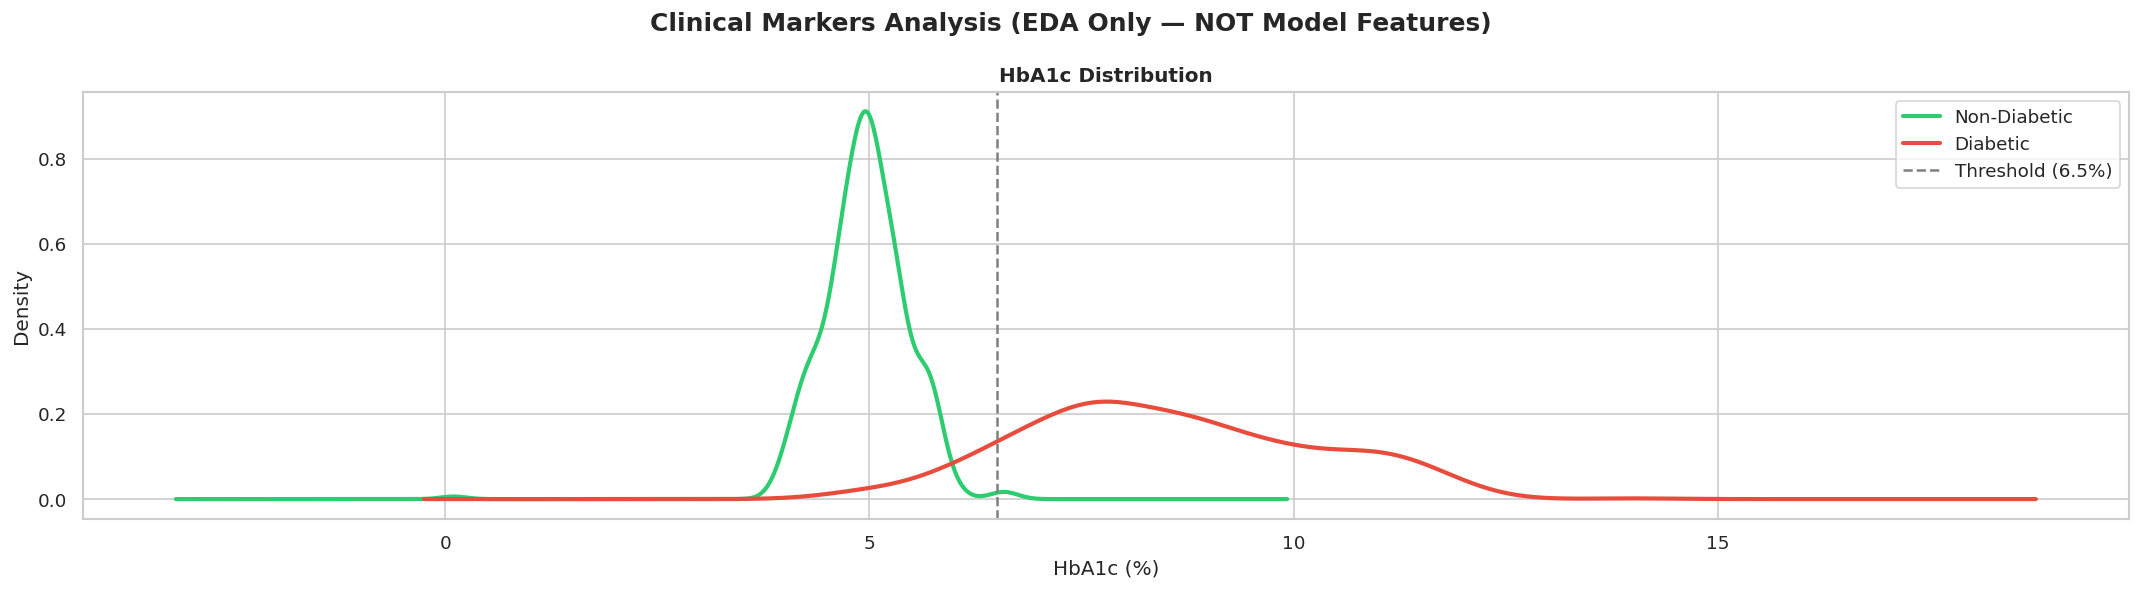

In [25]:
clinical_available = [c for c in ['Blood_Sugar', 'A1c'] if c in df.columns]

if len(clinical_available) == 0:
    print("Neither Blood_Sugar nor A1c found in dataframe. Check rename step.")
else:
    n_plots = len(clinical_available) + (1 if len(clinical_available) == 2 else 0)
    fig, axes = plt.subplots(1, max(n_plots, 1), figsize=(18, 5))
    if n_plots == 1:
        axes = [axes]

    ax_idx = 0
    if 'Blood_Sugar' in df.columns:
        for outcome, color, label in zip([0, 1], [C0, C1], ['Non-Diabetic', 'Diabetic']):
            subset = df[df['Outcome'] == outcome]['Blood_Sugar']
            subset.plot.kde(ax=axes[ax_idx], color=color, linewidth=2.5, label=label)
        axes[ax_idx].axvline(126, color='gray', linestyle='--', linewidth=1.5, label='Threshold (126)')
        axes[ax_idx].set_title('Blood Sugar Distribution', fontweight='bold')
        axes[ax_idx].set_xlabel('Blood Sugar (mg/dL)')
        axes[ax_idx].legend()
        ax_idx += 1

    if 'A1c' in df.columns:
        for outcome, color, label in zip([0, 1], [C0, C1], ['Non-Diabetic', 'Diabetic']):
            subset = df[df['Outcome'] == outcome]['A1c']
            subset.plot.kde(ax=axes[ax_idx], color=color, linewidth=2.5, label=label)
        axes[ax_idx].axvline(6.5, color='gray', linestyle='--', linewidth=1.5, label='Threshold (6.5%)')
        axes[ax_idx].set_title('HbA1c Distribution', fontweight='bold')
        axes[ax_idx].set_xlabel('HbA1c (%)')
        axes[ax_idx].legend()
        ax_idx += 1

    if 'Blood_Sugar' in df.columns and 'A1c' in df.columns and ax_idx < len(axes):
        for outcome, color, label in zip([0, 1], [C0, C1], ['Non-Diabetic', 'Diabetic']):
            subset = df[df['Outcome'] == outcome]
            axes[ax_idx].scatter(subset['A1c'], subset['Blood_Sugar'],
                                  alpha=0.5, color=color, label=label, s=40)
        axes[ax_idx].axhline(126, color='gray', linestyle='--', linewidth=1)
        axes[ax_idx].axvline(6.5, color='gray', linestyle='--', linewidth=1)
        axes[ax_idx].set_title('HbA1c vs Blood Sugar', fontweight='bold')
        axes[ax_idx].set_xlabel('HbA1c (%)')
        axes[ax_idx].set_ylabel('Blood Sugar (mg/dL)')
        axes[ax_idx].legend()

    plt.suptitle('Clinical Markers Analysis (EDA Only — NOT Model Features)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('clinical_markers.png', bbox_inches='tight')
    plt.show()

### Urban vs Rural Analysis


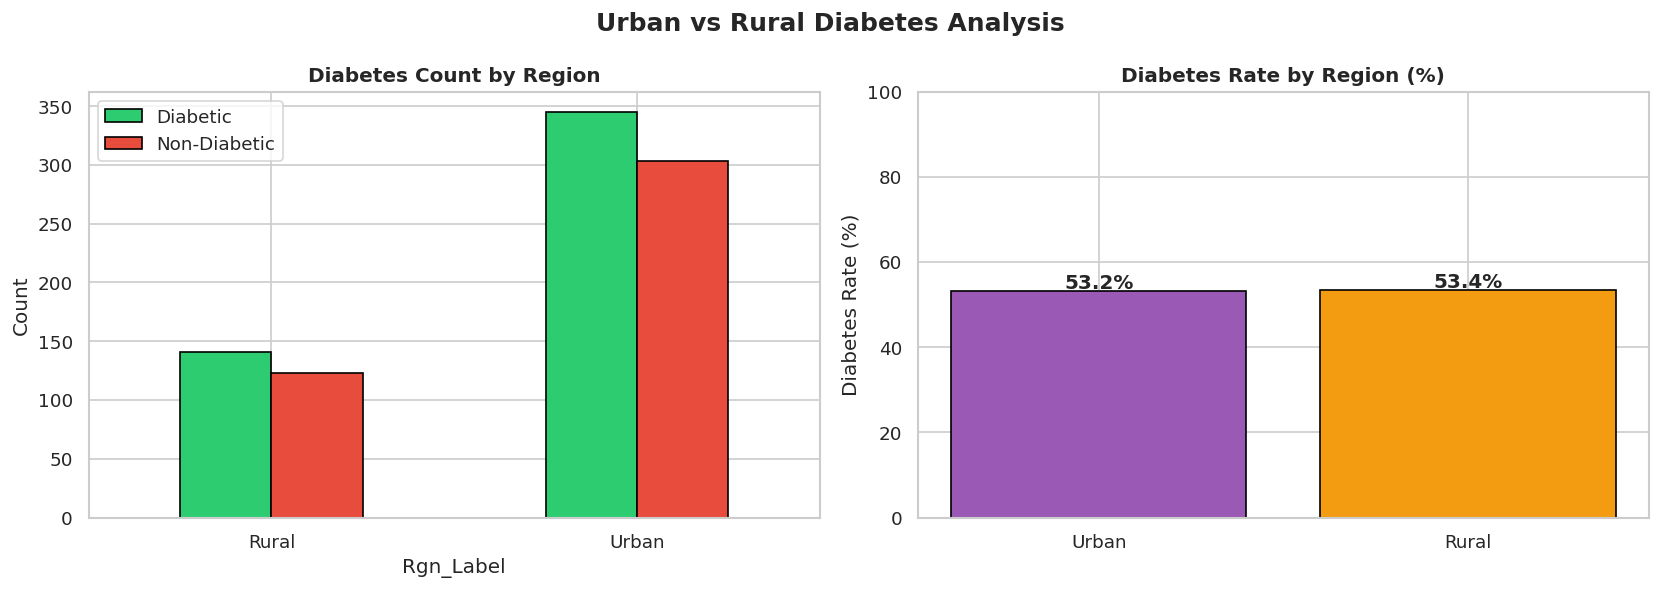

In [26]:
if 'Rgn' not in df.columns:
    print("Column 'Rgn' not found. Available columns:", list(df.columns))
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    region_outcome = df.groupby(['Rgn', 'Outcome']).size().reset_index(name='count')
    region_outcome['Rgn_Label'] = region_outcome['Rgn'].map({0: 'Urban', 1: 'Rural'})
    region_outcome['Outcome_Label'] = region_outcome['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

    pivot_region = region_outcome.pivot(index='Rgn_Label', columns='Outcome_Label', values='count').fillna(0)
    pivot_region.plot(kind='bar', ax=axes[0], color=[C0, C1], edgecolor='black', rot=0)
    axes[0].set_title('Diabetes Count by Region', fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    region_rate = df.groupby('Rgn')['Outcome'].mean() * 100
    rgn_labels = ['Urban' if r == 0 else 'Rural' for r in region_rate.index]
    bars = axes[1].bar(rgn_labels, region_rate.values,
                        color=['#9b59b6', '#f39c12'], edgecolor='black')
    for bar, val in zip(bars, region_rate.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontweight='bold')
    axes[1].set_title('Diabetes Rate by Region (%)', fontweight='bold')
    axes[1].set_ylabel('Diabetes Rate (%)')
    axes[1].set_ylim(0, 100)

    plt.suptitle('Urban vs Rural Diabetes Analysis', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('regional_analysis.png', bbox_inches='tight')
    plt.show()


### Binary Feature Analysis


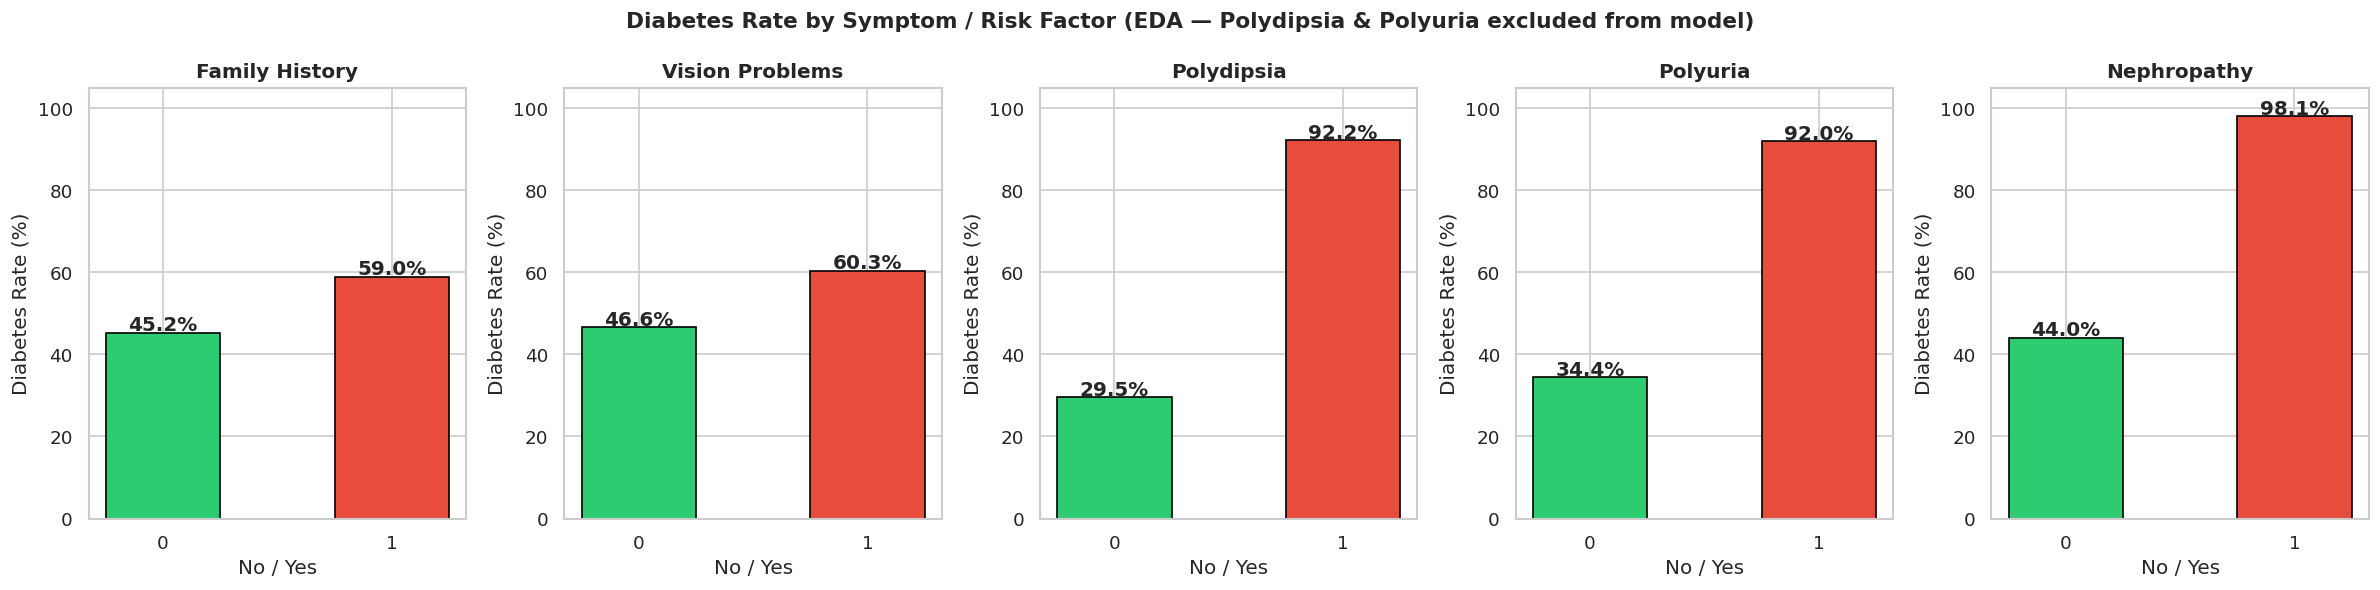

In [27]:
binary_cols_candidates = ['Family_History', 'Vision_Problems', 'Polydipsia', 'Polyuria', 'Nephropathy']
binary_cols = [c for c in binary_cols_candidates if c in df.columns]

fig, axes = plt.subplots(1, len(binary_cols), figsize=(20, 5))
if len(binary_cols) == 1:
    axes = [axes]

for i, col in enumerate(binary_cols):
    rate = df.groupby(col)['Outcome'].mean() * 100
    labels = [str(v) for v in rate.index]
    values = rate.values
    colors = [C0, C1] if len(values) >= 2 else [C0]
    bars = axes[i].bar(labels, values, color=colors, edgecolor='black', width=0.5)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontweight='bold')
    axes[i].set_title(col.replace('_', ' '), fontweight='bold')
    axes[i].set_xlabel('No / Yes')
    axes[i].set_ylabel('Diabetes Rate (%)')
    axes[i].set_ylim(0, 105)

plt.suptitle('Diabetes Rate by Symptom / Risk Factor (EDA — Polydipsia & Polyuria excluded from model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_features_analysis.png', bbox_inches='tight')
plt.show()

### BMI Category Analysis


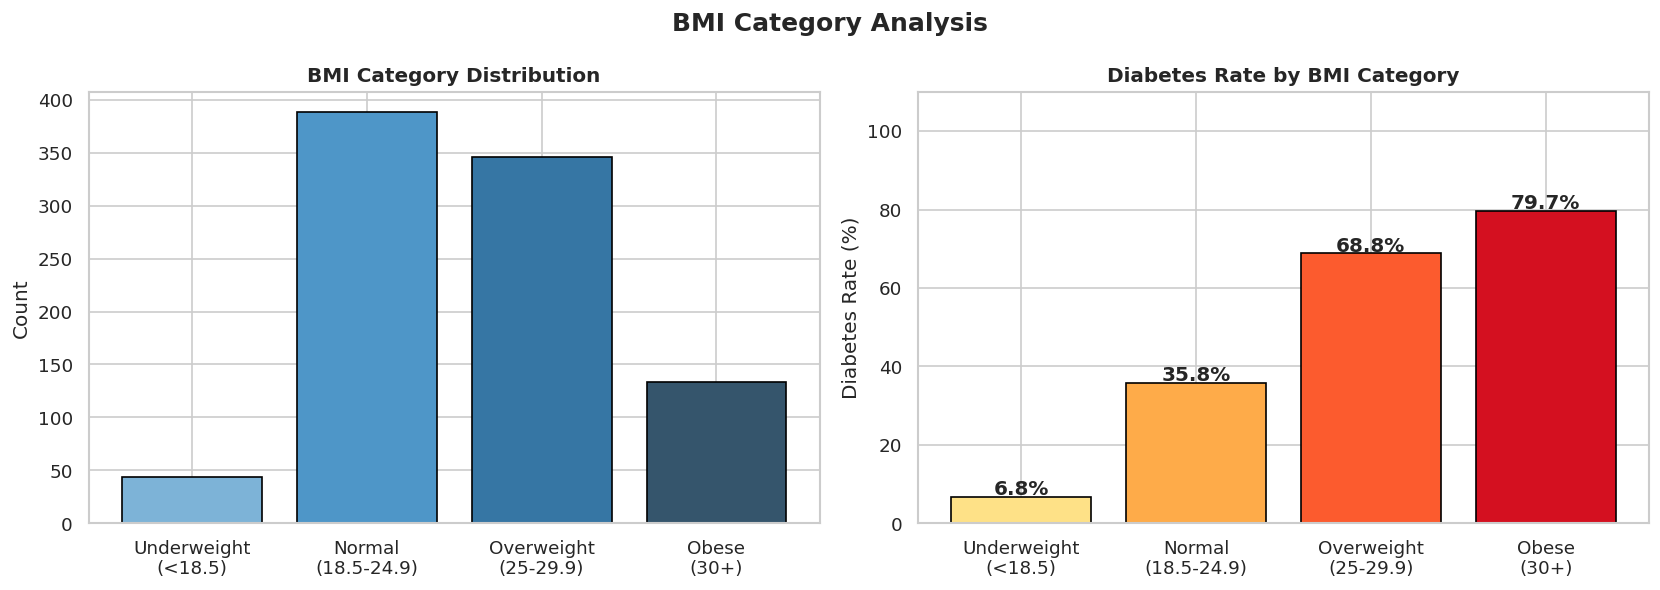

In [28]:
df['BMI_Category'] = pd.cut(df['BMI'], bins=[0, 18.5, 24.9, 29.9, 100],
                              labels=['Underweight\n(<18.5)', 'Normal\n(18.5-24.9)',
                                       'Overweight\n(25-29.9)', 'Obese\n(30+)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bmi_counts = df['BMI_Category'].value_counts().sort_index()
axes[0].bar(bmi_counts.index, bmi_counts.values,
             color=sns.color_palette('Blues_d', len(bmi_counts)), edgecolor='black')
axes[0].set_title('BMI Category Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

bmi_rate = df.groupby('BMI_Category', observed=True)['Outcome'].mean() * 100
bars = axes[1].bar(bmi_rate.index, bmi_rate.values,
                    color=sns.color_palette('YlOrRd', len(bmi_rate)), edgecolor='black')
for bar, val in zip(bars, bmi_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Diabetes Rate by BMI Category', fontweight='bold')
axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].set_ylim(0, 110)

plt.suptitle('BMI Category Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('bmi_analysis.png', bbox_inches='tight')
plt.show()

### Exercise & HDL Cholesterol Analysis



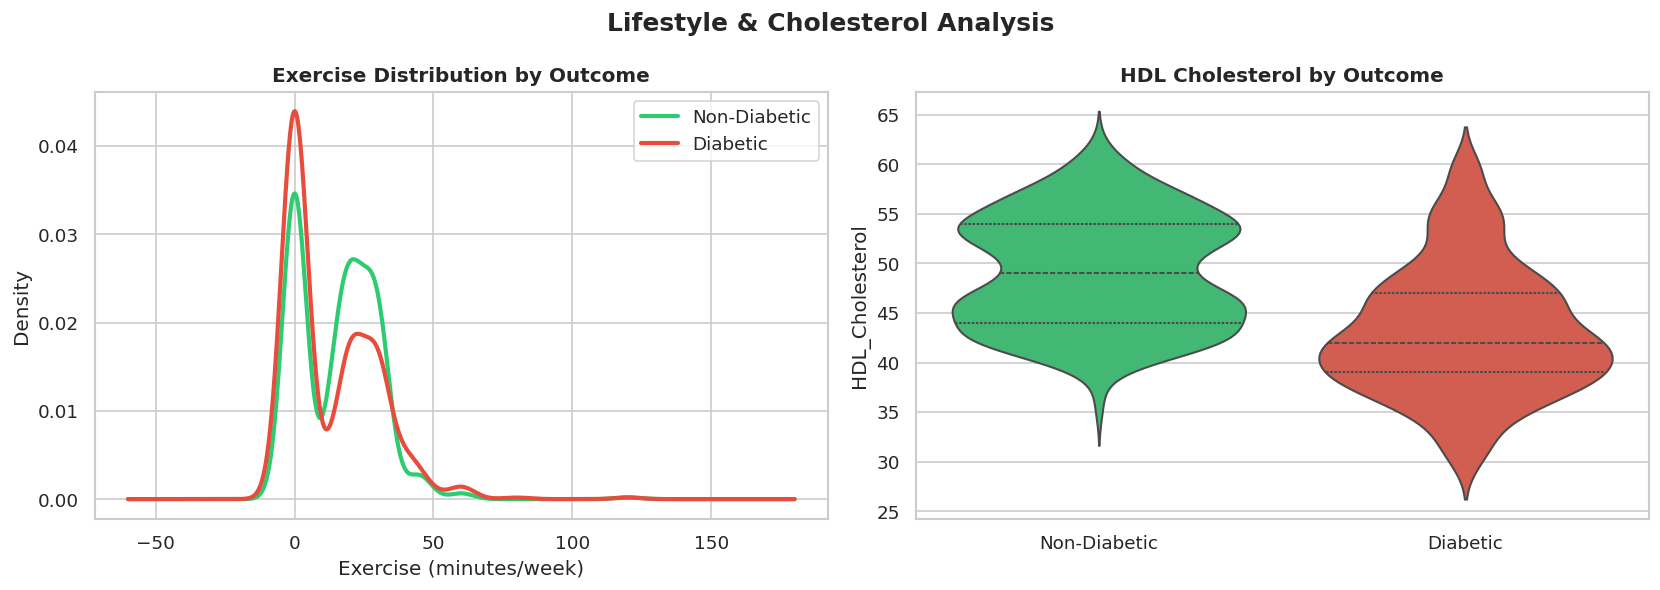

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'Exr' in df.columns:
    for outcome, color, label in zip([0, 1], [C0, C1], ['Non-Diabetic', 'Diabetic']):
        subset = df[df['Outcome'] == outcome]['Exr']
        subset.plot.kde(ax=axes[0], color=color, linewidth=2.5, label=label)
    axes[0].set_title('Exercise Distribution by Outcome', fontweight='bold')
    axes[0].set_xlabel('Exercise (minutes/week)')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "'Exr' column not found", ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Exercise Distribution — MISSING', fontweight='bold')

if 'HDL_Cholesterol' in df.columns:
    sns.violinplot(data=df, x='Outcome_Label', y='HDL_Cholesterol', ax=axes[1],
                   palette=PAL, order=['Non-Diabetic', 'Diabetic'], inner='quartile')
    axes[1].set_title('HDL Cholesterol by Outcome', fontweight='bold')
    axes[1].set_xlabel('')
else:
    axes[1].text(0.5, 0.5, "'HDL_Cholesterol' column not found", ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('Lifestyle & Cholesterol Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('lifestyle_analysis.png', bbox_inches='tight')
plt.show()


# Machine Learning



In [30]:
# Preparing features
LEAKAGE_COLS = [
    'Outcome', 'Outcome_Label', 'Age_Group', 'BMI_Category',
    'Duration',
    'A1c',
    'Polydipsia',
    'Polyuria',
    'B.S.R',
]

feature_cols = [c for c in df.columns if c not in LEAKAGE_COLS]

print(f"Features used for modelling ({len(feature_cols)}):")


Features used for modelling (13):


In [31]:
for f in feature_cols:
    print(f"  + {f}")

assert 'A1c' not in feature_cols, "ERROR: A1c is still in features."
assert 'Polydipsia' not in feature_cols, "ERROR: Polydipsia is still in features."
assert 'Polyuria' not in feature_cols, "ERROR: Polyuria is still in features."
assert 'B.S.R' not in feature_cols, "ERROR: B.S.R is still in features."
print("All leakage columns confirmed excluded from feature set.")

X = df[feature_cols].copy()
y = df['Outcome'].copy()

  + Age
  + Gender
  + Rgn
  + wt
  + BMI
  + wst
  + Systolic_BP
  + Diastolic_BP
  + Family_History
  + Vision_Problems
  + Exr
  + Nephropathy
  + HDL_Cholesterol
All leakage columns confirmed excluded from feature set.


### Train / Test Split


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')

Training set : (729, 13)
Test set     : (183, 13)


In [33]:
# Outlier capping on TRAIN only
clip_bounds = {}
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
num_feat_cols = X_train.select_dtypes(include=np.number).columns.tolist()

for col in num_feat_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    clip_bounds[col] = (lower, upper)
    X_train_clean[col] = X_train[col].clip(lower, upper)
    X_test_clean[col]  = X_test[col].clip(lower, upper)  # use TRAIN bounds!

print(f'Outliers capped. Clean dataset shape: {X_train_clean.shape}')

Outliers capped. Clean dataset shape: (729, 13)


### Feature Scaling


In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled  = scaler.transform(X_test_clean)
print('Features scaled.')

Features scaled.


### Defining & Training All Models


In [35]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                         eval_metric='logloss', random_state=42),
    'SVM':                 SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred   = model.predict(X_test_scaled)
    y_prob   = model.predict_proba(X_test_scaled)[:, 1]
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1 Score':  f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
        'CV Mean':   cv_scores.mean(),
        'CV Std':    cv_scores.std(),
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }
    trained_models[name] = model
    print(f'{name:<22} | Accuracy: {results[name]["Accuracy"]:.3f} | ROC-AUC: {results[name]["ROC-AUC"]:.3f}')

Logistic Regression    | Accuracy: 0.923 | ROC-AUC: 0.975
Decision Tree          | Accuracy: 0.918 | ROC-AUC: 0.943
Random Forest          | Accuracy: 0.934 | ROC-AUC: 0.986
XGBoost                | Accuracy: 0.940 | ROC-AUC: 0.988
SVM                    | Accuracy: 0.945 | ROC-AUC: 0.979


# Model Evaluation

### Performance Comparison Table


In [36]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  round(r['Accuracy'], 4),
        'Precision': round(r['Precision'], 4),
        'Recall':    round(r['Recall'], 4),
        'F1 Score':  round(r['F1 Score'], 4),
        'ROC-AUC':   round(r['ROC-AUC'], 4),
        'CV Score':  f"{r['CV Mean']:.3f} ± {r['CV Std']:.3f}"
    }
    for name, r in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

display(metrics_df)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Score
XGBoost,0.9399,0.9307,0.9592,0.9447,0.9881,0.941 ± 0.018
Random Forest,0.9344,0.9135,0.9694,0.9406,0.9858,0.938 ± 0.025
SVM,0.9454,0.94,0.9592,0.9495,0.9789,0.930 ± 0.021
Logistic Regression,0.9235,0.9286,0.9286,0.9286,0.975,0.922 ± 0.025
Decision Tree,0.918,0.9109,0.9388,0.9246,0.9432,0.929 ± 0.017


In [37]:
best_model_name = max(results, key=lambda k: results[k]['ROC-AUC'])
best_model = trained_models[best_model_name]

print(f"Best model selected: {best_model_name}")

Best model selected: XGBoost


### Classification Report

In [38]:
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=["Non-Diabetic", "Diabetic"]))



Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.95      0.92      0.93        85
    Diabetic       0.93      0.96      0.94        98

    accuracy                           0.94       183
   macro avg       0.94      0.94      0.94       183
weighted avg       0.94      0.94      0.94       183



### Confusion Matrix

<Figure size 720x600 with 0 Axes>

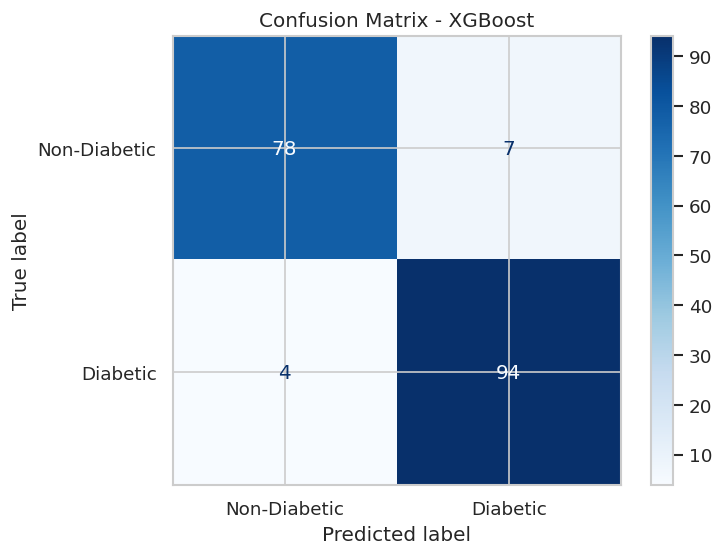

In [39]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Diabetic", "Diabetic"])

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

### ROC Curve for the Best Model

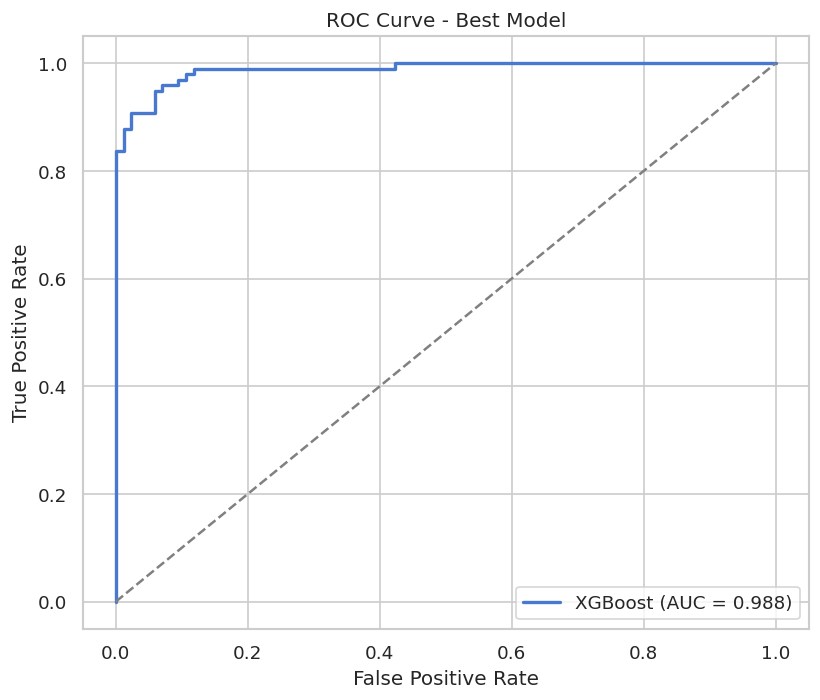

In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
auc_value = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc_value:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_best_model.png", bbox_inches="tight")
plt.show()

### Metrics Bar Chart


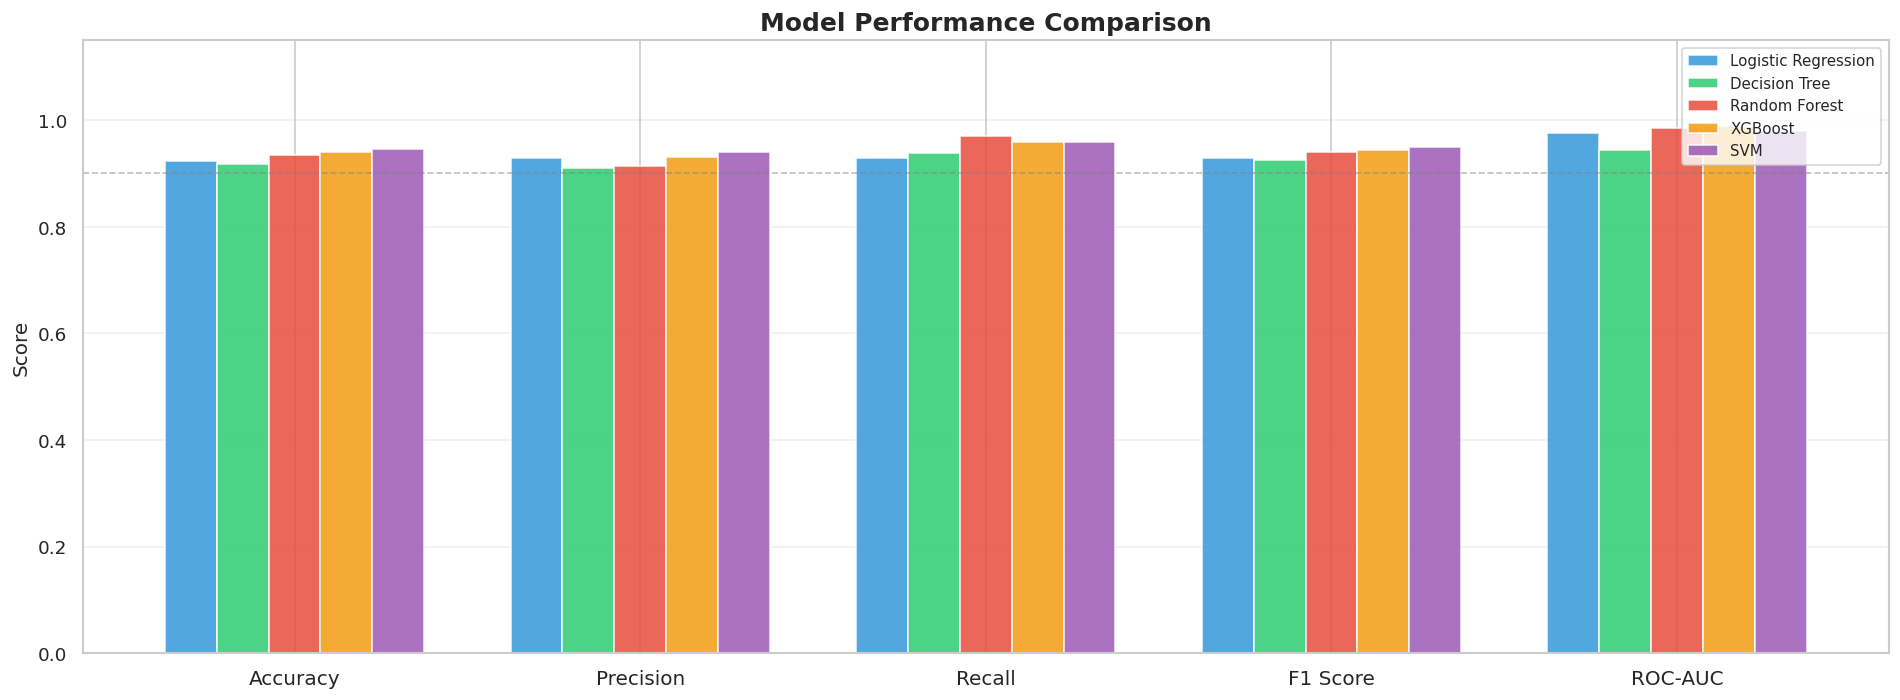

In [41]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
plot_data = {name: [results[name][m] for m in metric_names] for name in results}
x = np.arange(len(metric_names))
width = 0.15
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (name, vals) in enumerate(plot_data.items()):
    offset = (i - len(plot_data) / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=name, color=colors_bar[i], edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

### Confusion Matrices for All Models


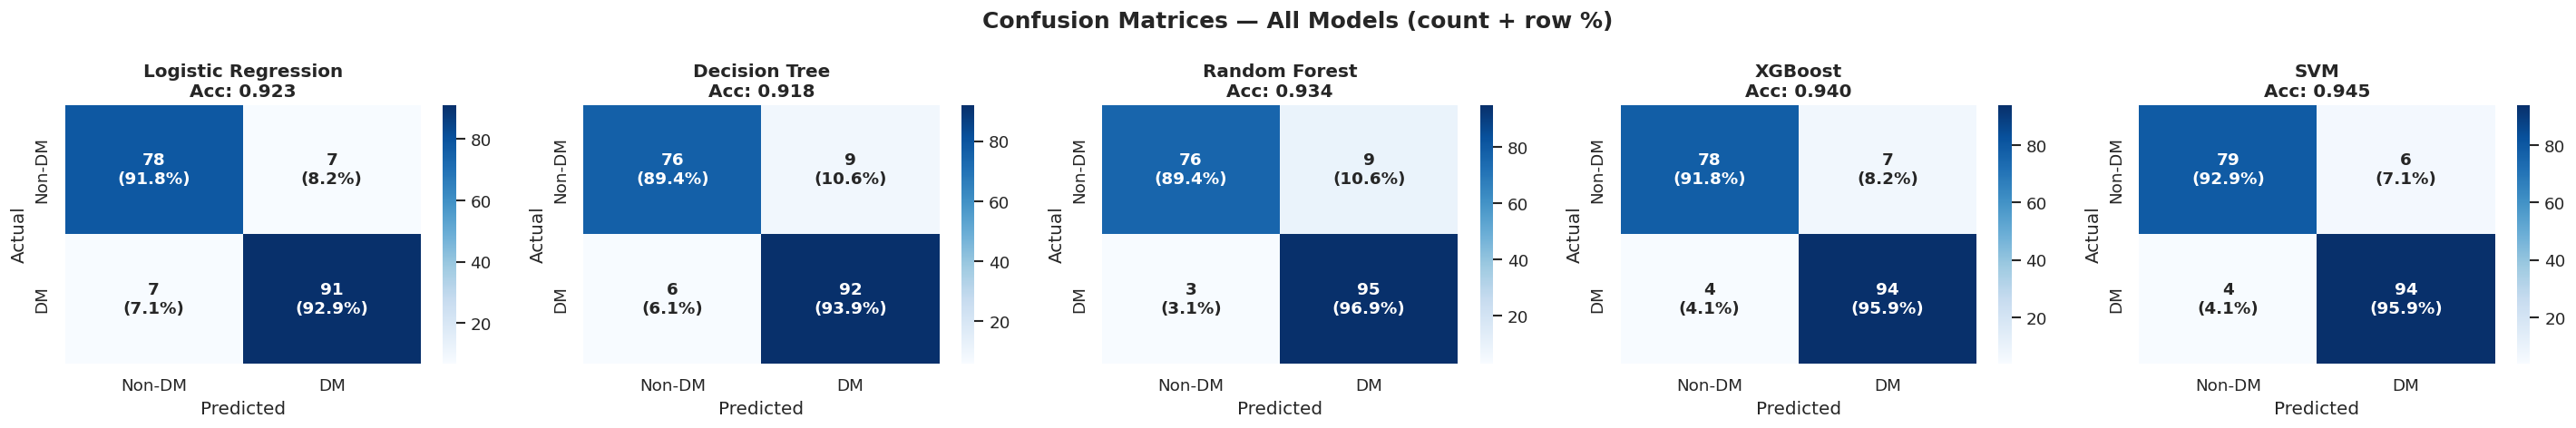

In [42]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
                       for row_v, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=labels, fmt='', ax=ax, cmap='Blues',
                xticklabels=['Non-DM', 'DM'], yticklabels=['Non-DM', 'DM'],
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(f'{name}\nAcc: {r["Accuracy"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models (count + row %)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

### ROC Curves of All Models


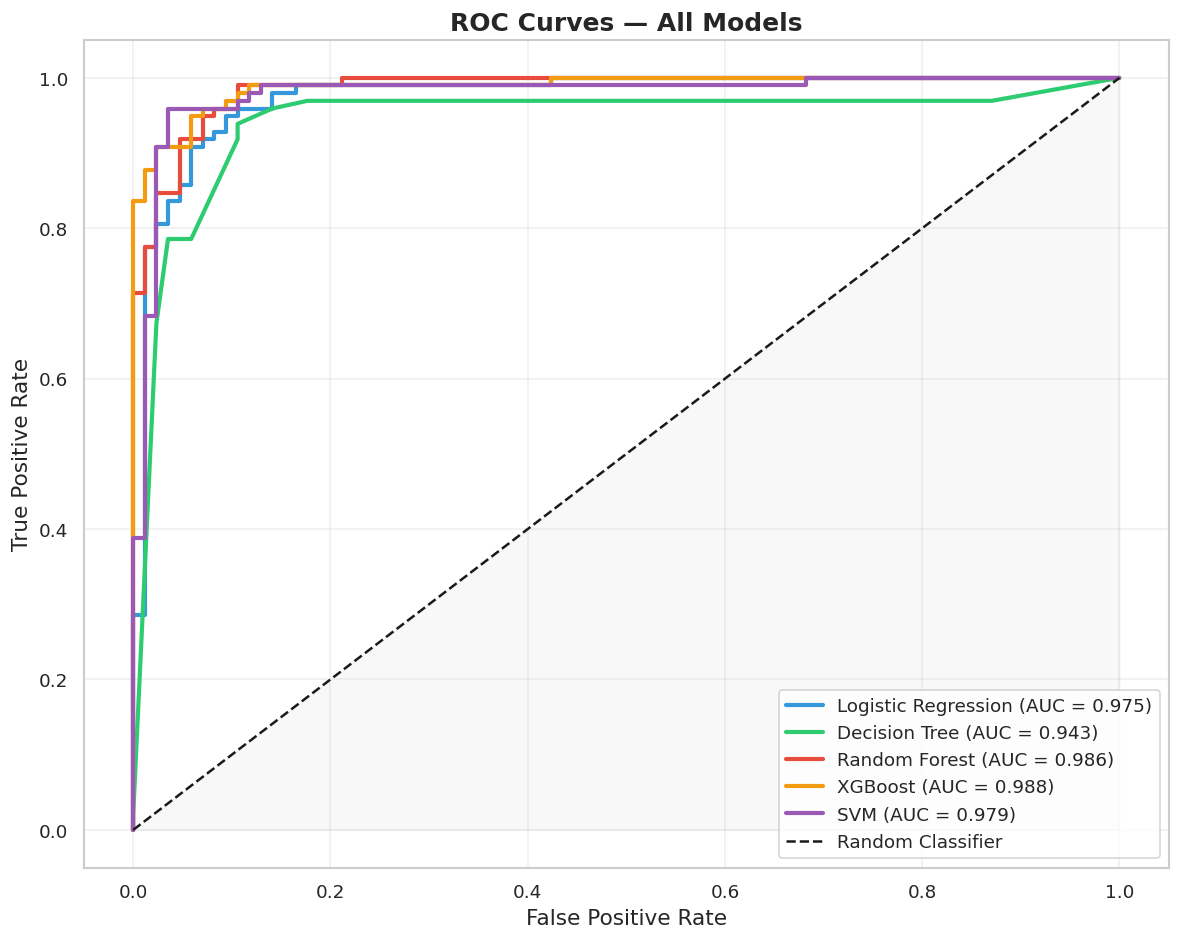

In [43]:
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
plt.figure(figsize=(10, 8))
for (name, r), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, lw=2.5, color=color, label=f'{name} (AUC = {r["ROC-AUC"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

### Precision-Recall Curves of All Models


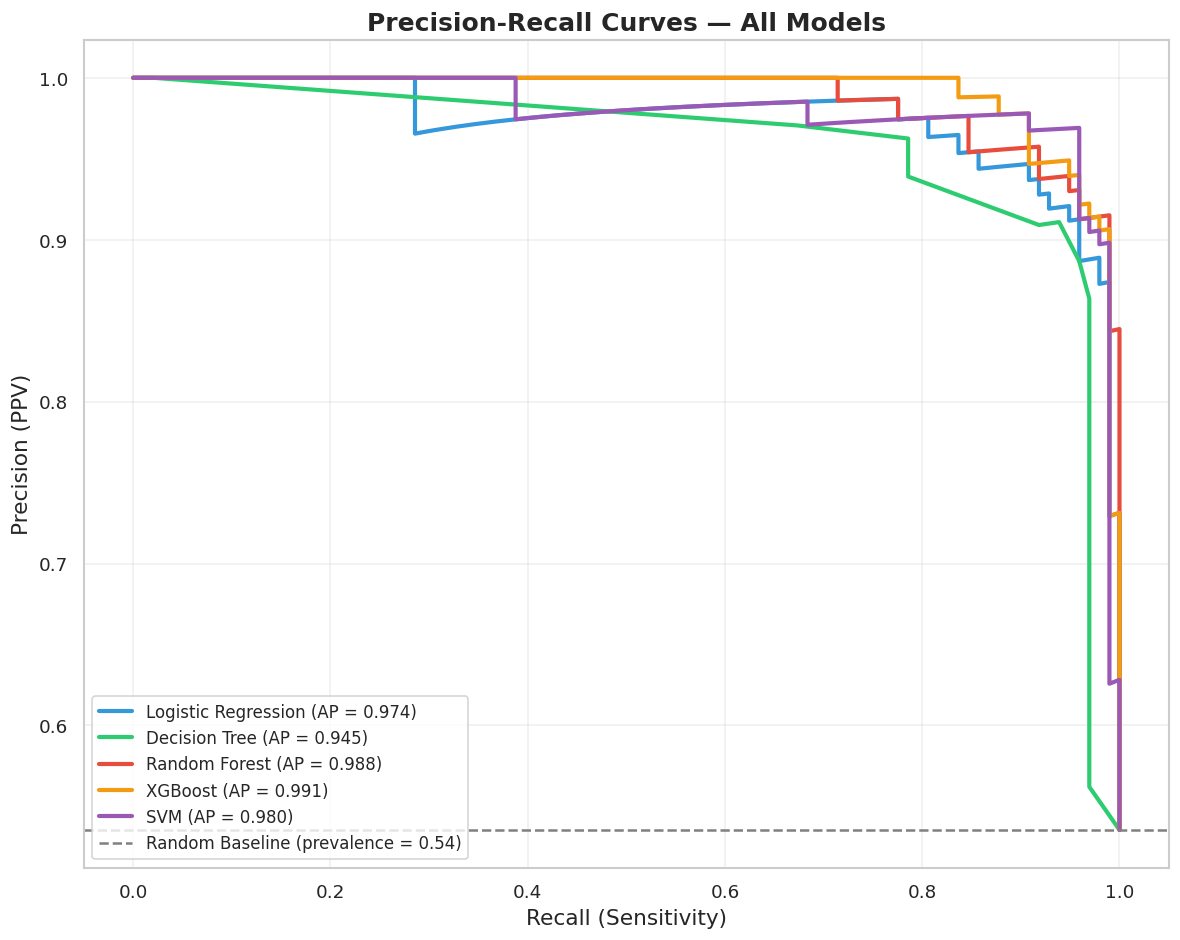

In [45]:
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
plt.figure(figsize=(10, 8))

for (name, r), color in zip(results.items(), colors_roc):
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    ap = average_precision_score(y_test, r['y_prob'])
    plt.plot(rec, prec, lw=2.5, color=color, label=f'{name} (AP = {ap:.3f})')

baseline = y_test.mean()
plt.axhline(baseline, color='gray', linestyle='--', linewidth=1.5,
            label=f'Random Baseline (prevalence = {baseline:.2f})')

plt.xlabel('Recall (Sensitivity)', fontsize=13)
plt.ylabel('Precision (PPV)', fontsize=13)
plt.title('Precision-Recall Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', bbox_inches='tight')
plt.show()

### Feature Importance — Random Forest


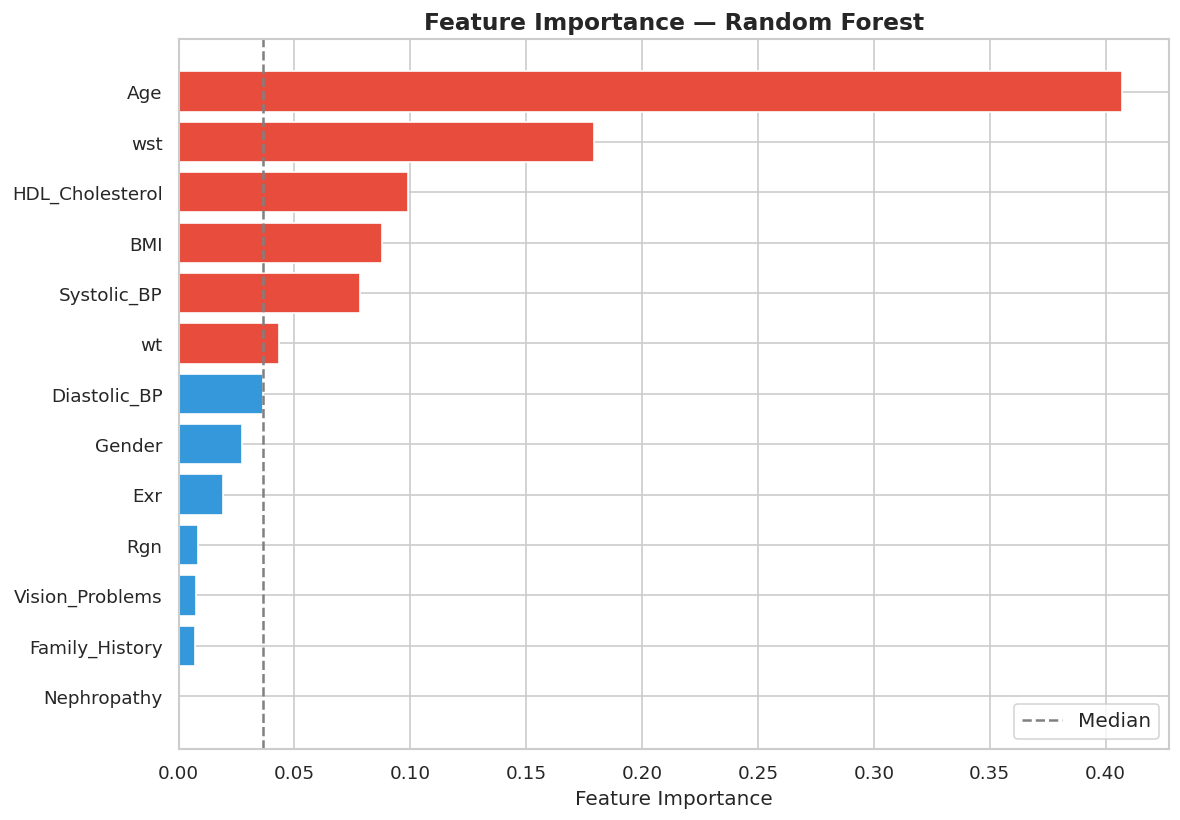

In [46]:
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
colors_imp = ['#e74c3c' if imp > importances.median() else '#3498db' for imp in importances]

plt.figure(figsize=(10, 7))
plt.barh(importances.index, importances.values, color=colors_imp, edgecolor='white')
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.axvline(importances.median(), color='gray', linestyle='--', linewidth=1.5, label='Median')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_rf.png', bbox_inches='tight')
plt.show()

### Feature Importance — XGBoost


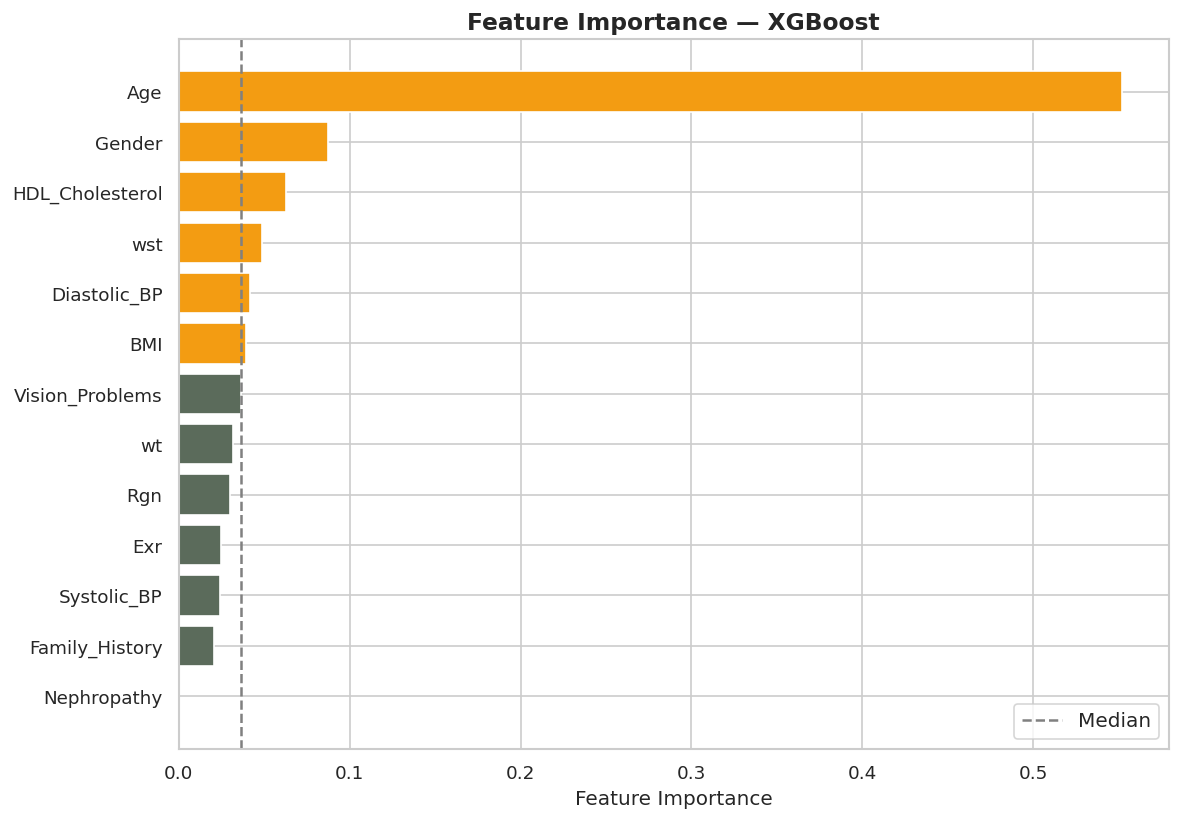

In [47]:
xgb_model = trained_models['XGBoost']
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
colors_xgb = ['#f39c12' if imp > xgb_importances.median() else '#5b6b5b' for imp in xgb_importances]

plt.figure(figsize=(10, 7))
plt.barh(xgb_importances.index, xgb_importances.values, color=colors_xgb, edgecolor='white')
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Feature Importance — XGBoost', fontsize=14, fontweight='bold')
plt.axvline(xgb_importances.median(), color='gray', linestyle='--', linewidth=1.5, label='Median')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', bbox_inches='tight')
plt.show()

### SHAP Values for XGBoost Explainability

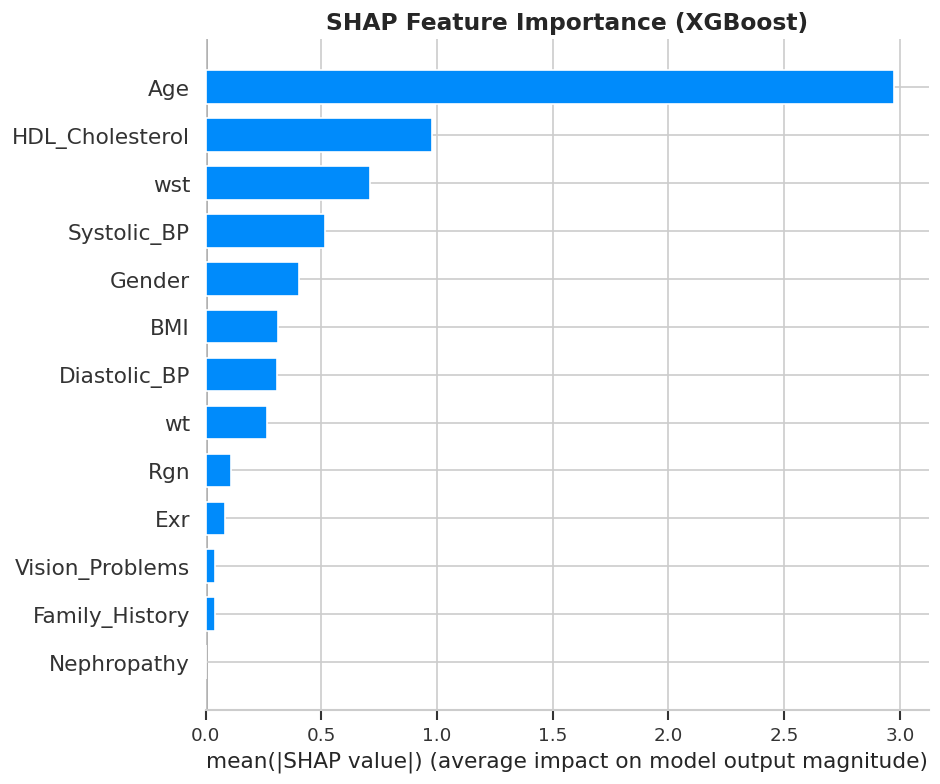

In [48]:
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols)
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()


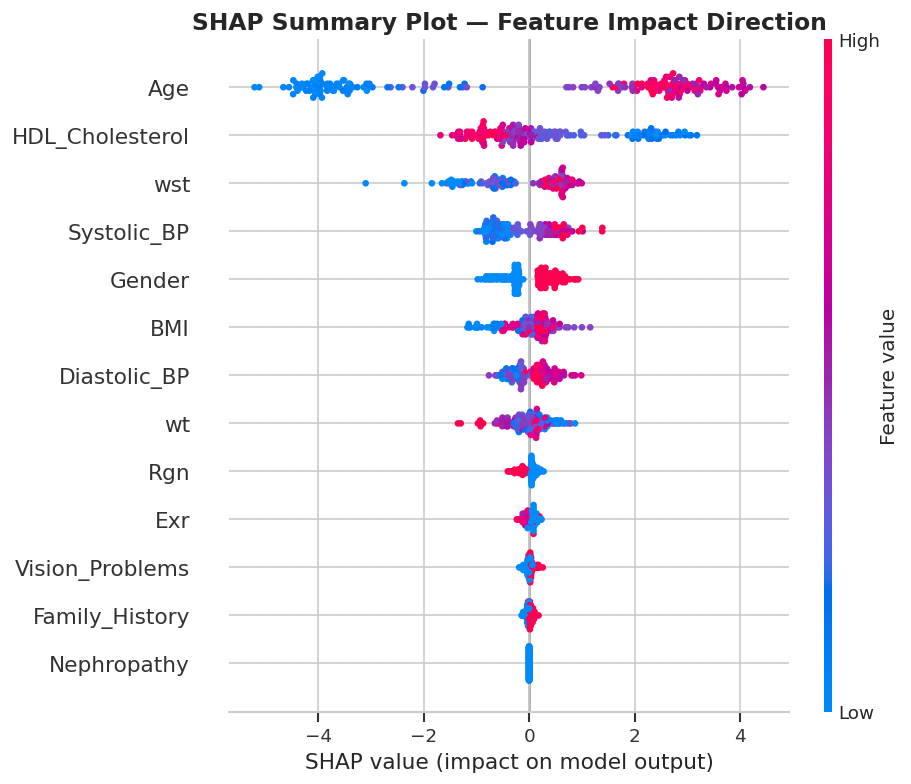

In [49]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title('SHAP Summary Plot — Feature Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight')
plt.show()

### 5-Fold Cross Validation Scores


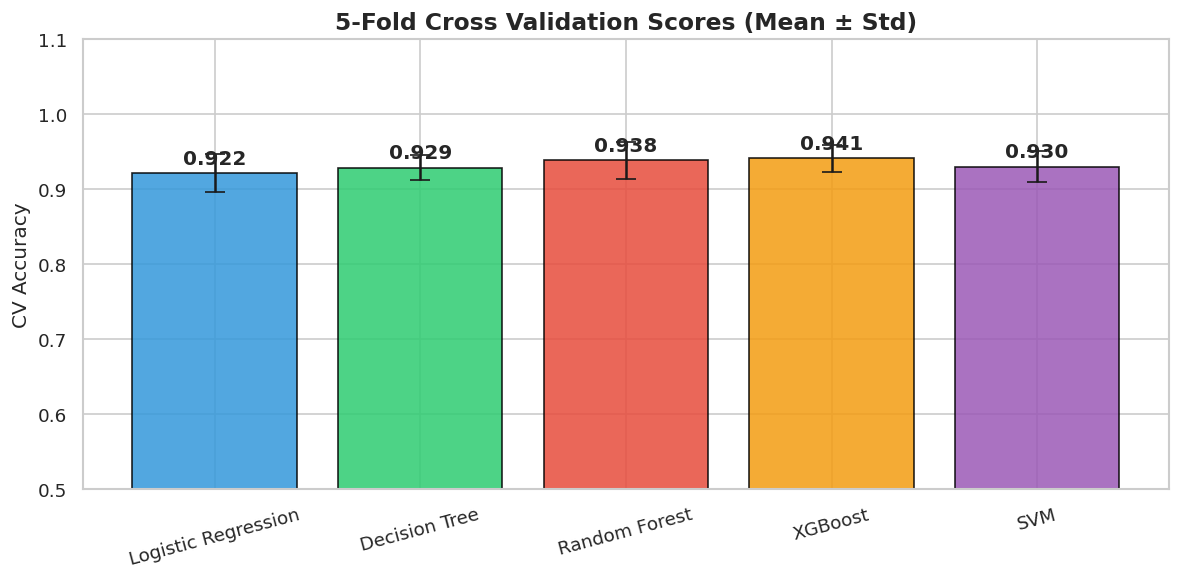

In [50]:
cv_means = [results[name]['CV Mean'] for name in results]
cv_stds  = [results[name]['CV Std']  for name in results]
model_names = list(results.keys())

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, cv_means, yerr=cv_stds, capsize=6,
               color=colors_bar, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f'{val:.3f}', ha='center', fontweight='bold')
plt.ylim(0.5, 1.10)
plt.ylabel('CV Accuracy', fontsize=12)
plt.title('5-Fold Cross Validation Scores (Mean ± Std)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('cv_scores.png', bbox_inches='tight')
plt.show()

In [51]:
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=rkf,
        scoring="accuracy"
    )

    cv_results[name] = {
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "CV Min": cv_scores.min(),
        "CV Max": cv_scores.max()
    }

cv_df = pd.DataFrame(cv_results).T.sort_values(
    "CV Mean",
    ascending=False
)

print(cv_df)

                      CV Mean    CV Std    CV Min    CV Max
Random Forest        0.934432  0.016344  0.897260  0.972603
XGBoost              0.930182  0.019461  0.890411  0.972603
SVM                  0.930045  0.018401  0.889655  0.965517
Logistic Regression  0.918937  0.021344  0.863014  0.958621
Decision Tree        0.918784  0.019162  0.876712  0.965753


### Model Calibration Curves


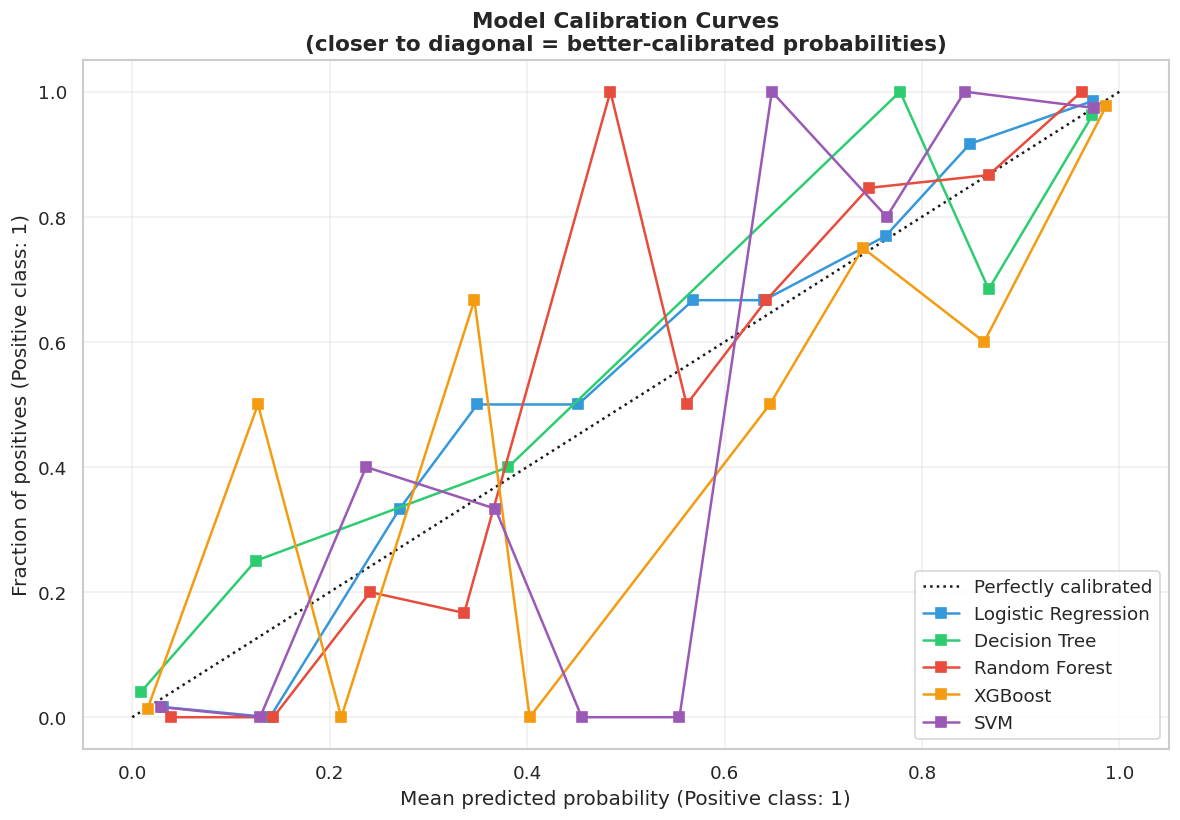

In [52]:
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
fig, ax = plt.subplots(figsize=(10, 7))

for (name, r), color in zip(results.items(), colors_roc):
    CalibrationDisplay.from_predictions(
        y_test, r['y_prob'],
        n_bins=10, ax=ax, name=name,
        color=color
    )

ax.set_title('Model Calibration Curves\n(closer to diagonal = better-calibrated probabilities)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curves.png', bbox_inches='tight')
plt.show()


#  Conclusions

In [54]:
best_model = max(results, key=lambda x: results[x]['ROC-AUC'])
best_acc   = max(results, key=lambda x: results[x]['Accuracy'])
best_f1    = max(results, key=lambda x: results[x]['F1 Score'])

print('FINAL MODEL SUMMARY:')
print(f'  Best ROC-AUC : {best_model} ({results[best_model]["ROC-AUC"]:.4f})')
print(f'  Best Accuracy: {best_acc} ({results[best_acc]["Accuracy"]:.3f})')
print(f'  Best F1 Score: {best_f1} ({results[best_f1]["F1 Score"]:.3f})')

FINAL MODEL SUMMARY:
  Best ROC-AUC : XGBoost (0.9881)
  Best Accuracy: SVM (0.945)
  Best F1 Score: SVM (0.949)


In [55]:
print('TOP 3 DIABETES PREDICTORS: ')
top3 = xgb_importances.sort_values(ascending=False).head(3)
for feat, imp in top3.items():
    print(f'  + {feat}: {imp:.4f}')

TOP 3 DIABETES PREDICTORS: 
  + Age: 0.5516
  + Gender: 0.0875
  + HDL_Cholesterol: 0.0631


In [56]:
print('CLINICAL FINDINGS : ')
if 'Blood_Sugar' in df.columns:
    print(f"  Mean Blood Sugar — Diabetic     : {df[df['Outcome']==1]['Blood_Sugar'].mean():.1f} mg/dL")
    print(f"  Mean Blood Sugar — Non-Diabetic : {df[df['Outcome']==0]['Blood_Sugar'].mean():.1f} mg/dL")
if 'A1c' in df.columns:
    print(f"  Mean HbA1c — Diabetic           : {df[df['Outcome']==1]['A1c'].mean():.2f}%")
    print(f"  Mean HbA1c — Non-Diabetic       : {df[df['Outcome']==0]['A1c'].mean():.2f}%")
print(f"  Diabetes Prevalence             : {df['Outcome'].mean()*100:.1f}%")


CLINICAL FINDINGS : 
  Mean HbA1c — Diabetic           : 8.53%
  Mean HbA1c — Non-Diabetic       : 4.96%
  Diabetes Prevalence             : 53.3%


In [57]:
print('Recommended Model for Prototype/Further Validation: XGBoost')
print('Best balance of accuracy, AUC, and interpretability via SHAP')
print('Note: External validation on new data required before clinical deployment.')

Recommended Model for Prototype/Further Validation: XGBoost
Best balance of accuracy, AUC, and interpretability via SHAP
Note: External validation on new data required before clinical deployment.
